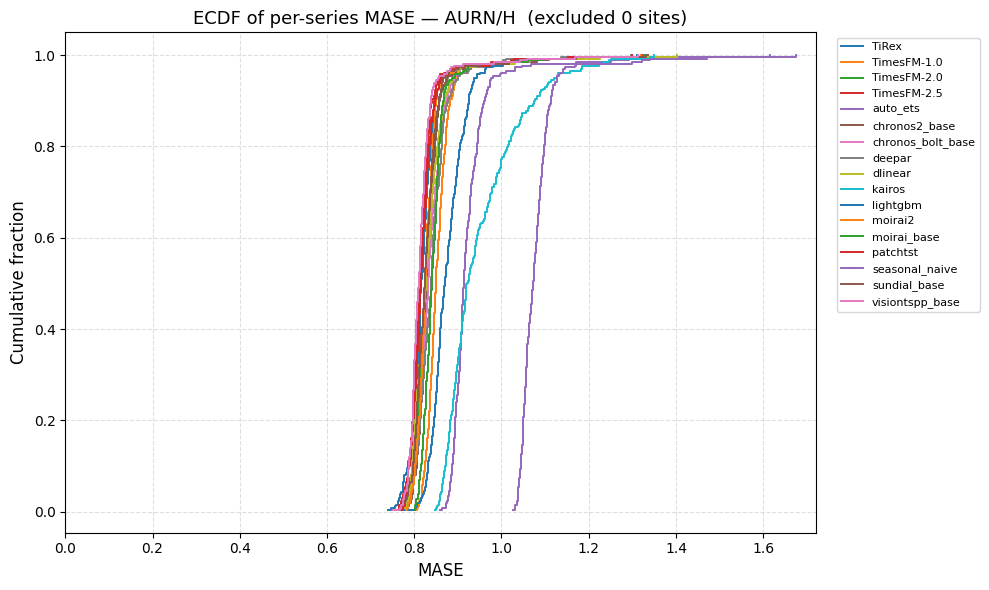

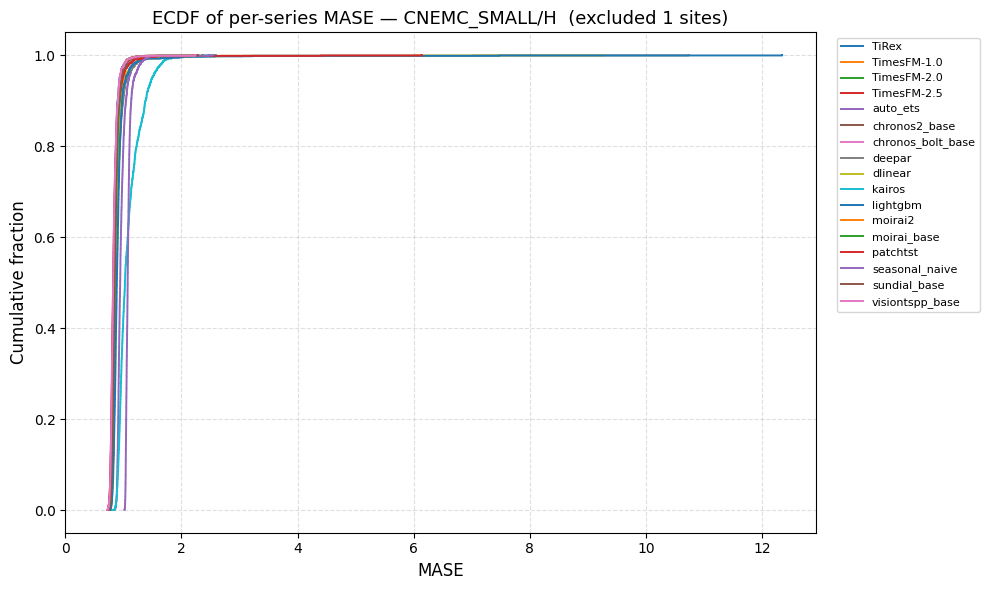

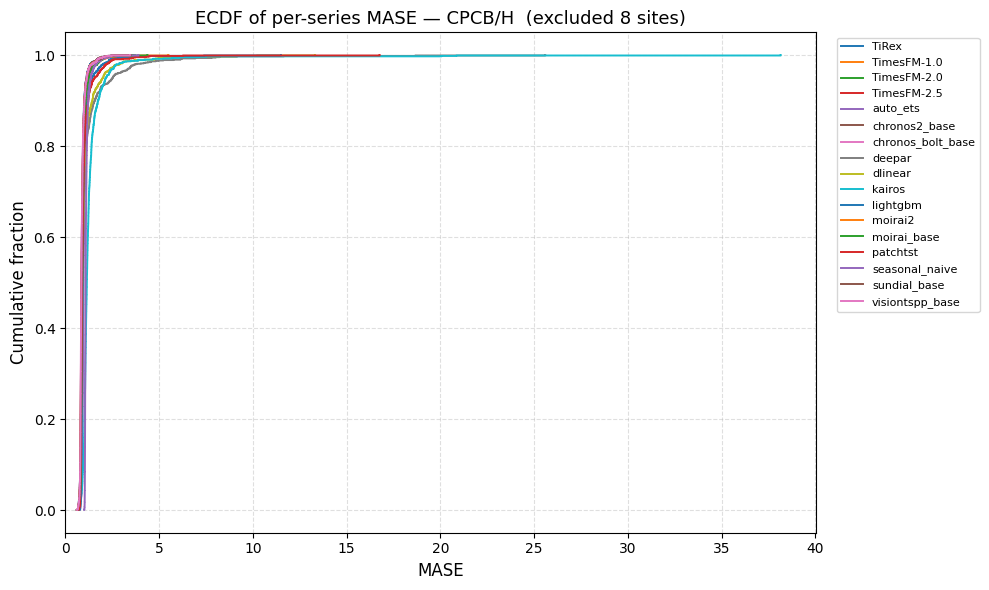

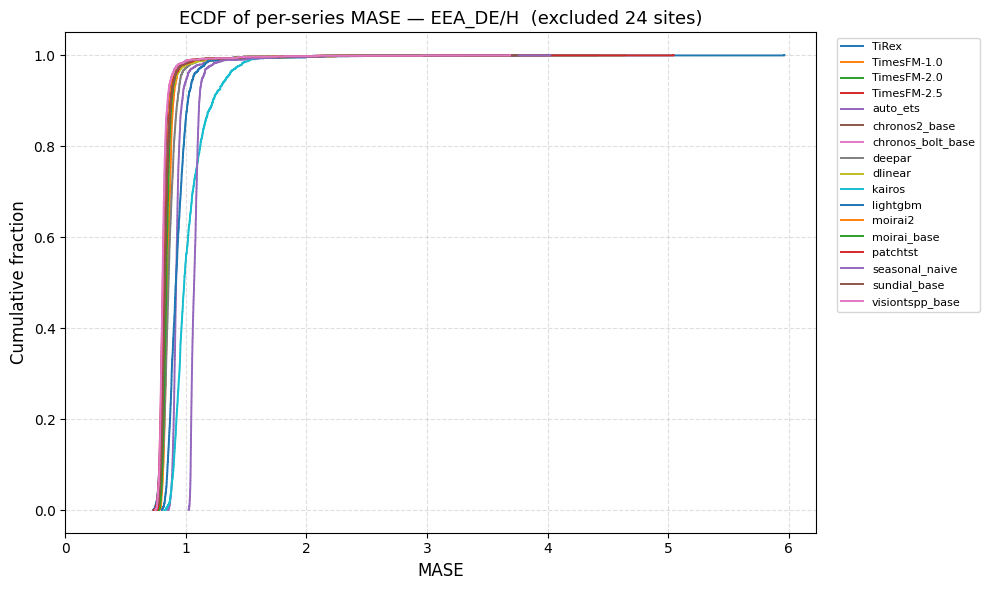

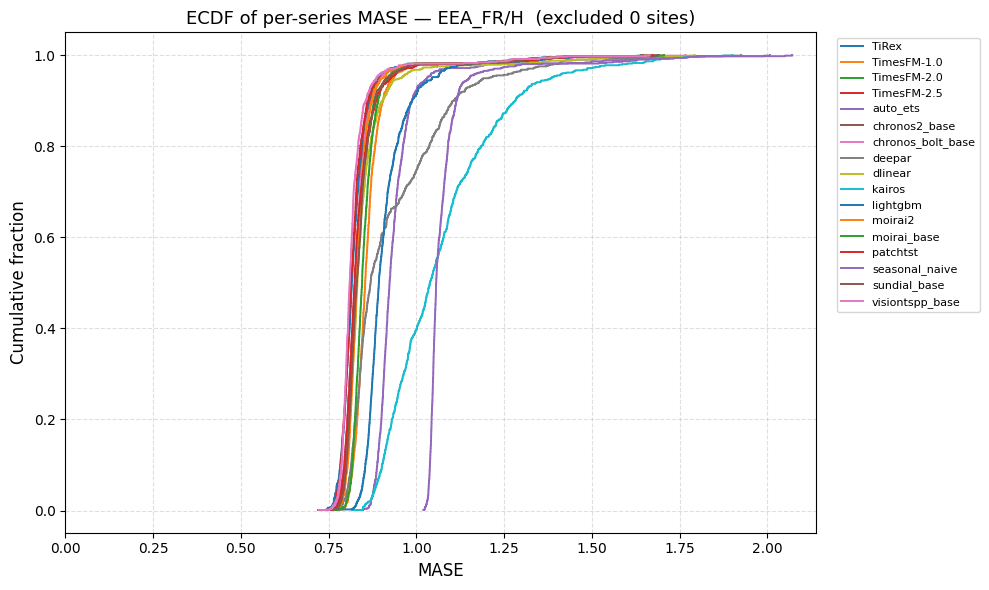

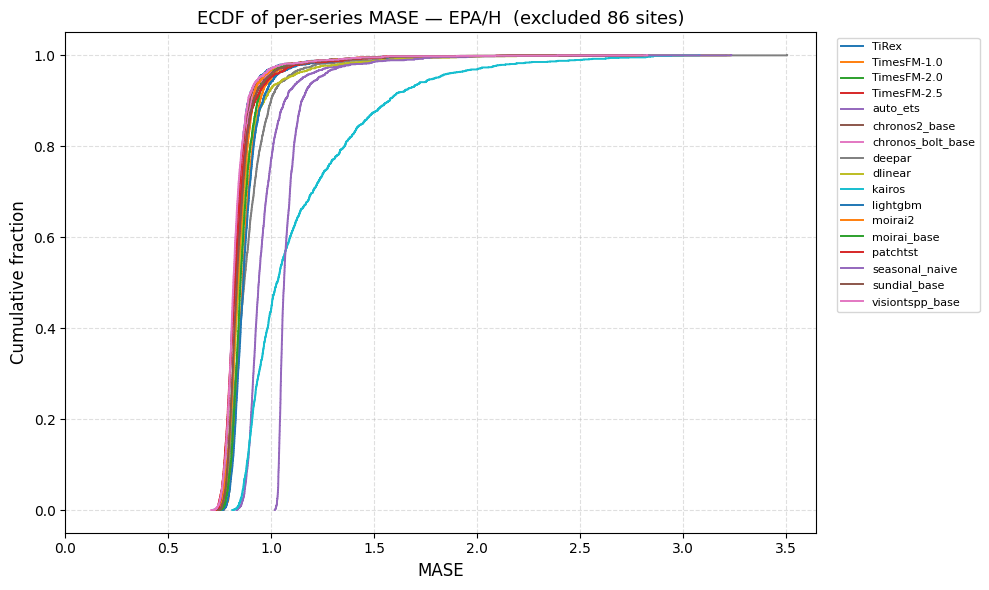

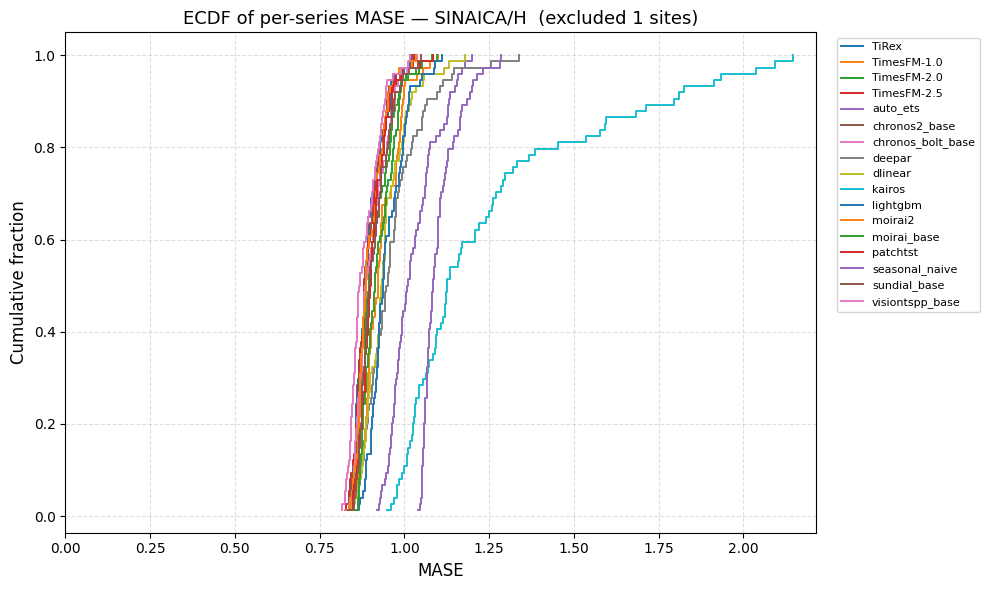

In [18]:
import sys
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path(".").resolve()))
sys.path.insert(0, str(Path("scripts").resolve()))

from compute_local_leaderboard import _iter_model_series

RESULTS_ROOT = Path("output/results")
THRESHOLD    = 5

# ── Discover all dataset_ids present in results ───────────────────────────────
dataset_ids = sorted({
    f"{d.name}/{f.name}"
    for model_dir in RESULTS_ROOT.iterdir() if model_dir.is_dir()
    for d in model_dir.iterdir() if d.is_dir()
    for f in d.iterdir() if f.is_dir()
})


def _excluded_sites(dataset_id: str) -> set[str]:
    """
    Mirror of the Pass-1 exclusion logic in get_per_pollutant_results:
    collect per-site mean MASE and CRPS across ALL models, exclude any site
    where either mean > THRESHOLD (50).
    """
    site_vals: dict[str, dict[str, list[float]]] = {"MASE": {}, "CRPS": {}}

    for model_name, ds_id, horizon, item_ids, npz_metrics in _iter_model_series(
        RESULTS_ROOT, [dataset_id]
    ):
        for metric in ("MASE", "CRPS"):
            arr = npz_metrics.get(metric)
            if arr is None or arr.shape[0] != len(item_ids):
                continue
            reduce_axes = tuple(range(1, arr.ndim))
            per_series = np.nanmean(arr, axis=reduce_axes) if reduce_axes else arr
            for iid, val in zip(item_ids, per_series):
                if not np.isnan(val):
                    site_vals[metric].setdefault(iid, []).append(float(val))

    excluded = set()
    for iid in set(site_vals["MASE"]) | set(site_vals["CRPS"]):
        mase_mean = np.mean(site_vals["MASE"][iid]) if site_vals["MASE"].get(iid) else 0
        crps_mean = np.mean(site_vals["CRPS"][iid]) if site_vals["CRPS"].get(iid) else 0
        if mase_mean > THRESHOLD or crps_mean > THRESHOLD:
            excluded.add(iid)
    return excluded


# ── One ECDF plot per dataset ─────────────────────────────────────────────────
for dataset_id in dataset_ids:
    excluded = _excluded_sites(dataset_id)

    model_mase: dict[str, list[float]] = {}

    for model_name, _, horizon, item_ids, npz_metrics in _iter_model_series(
        RESULTS_ROOT, [dataset_id]
    ):
        arr = npz_metrics.get("MASE")
        if arr is None:
            continue
        n_series = len(item_ids)
        reduce_axes = tuple(range(1, arr.ndim))
        per_series = np.nanmean(arr[:n_series], axis=reduce_axes) if reduce_axes else arr[:n_series]
        for iid, val in zip(item_ids, per_series):
            if iid not in excluded:
                model_mase.setdefault(model_name, []).append(val)

    if not model_mase:
        continue

    fig, ax = plt.subplots(figsize=(10, 6))
    for model_name, values in sorted(model_mase.items()):
        vals = np.sort([v for v in values if not np.isnan(v)])
        ecdf = np.arange(1, len(vals) + 1) / len(vals)
        ax.step(vals, ecdf, label=model_name, where="post", linewidth=1.4)

    ax.set_xlim(left=0)
    ax.set_xlabel("MASE", fontsize=12)
    ax.set_ylabel("Cumulative fraction", fontsize=12)
    ax.set_title(f"ECDF of per-series MASE — {dataset_id}  (excluded {len(excluded)} sites)", fontsize=13)
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8, framealpha=0.8)
    ax.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()


CPCB/H: 1 site(s) excluded (mean MASE or CRPS > 50)
CNEMC_SMALL/H: 0 site(s) excluded (mean MASE or CRPS > 50)
EPA/H: 55 site(s) excluded (mean MASE or CRPS > 50)


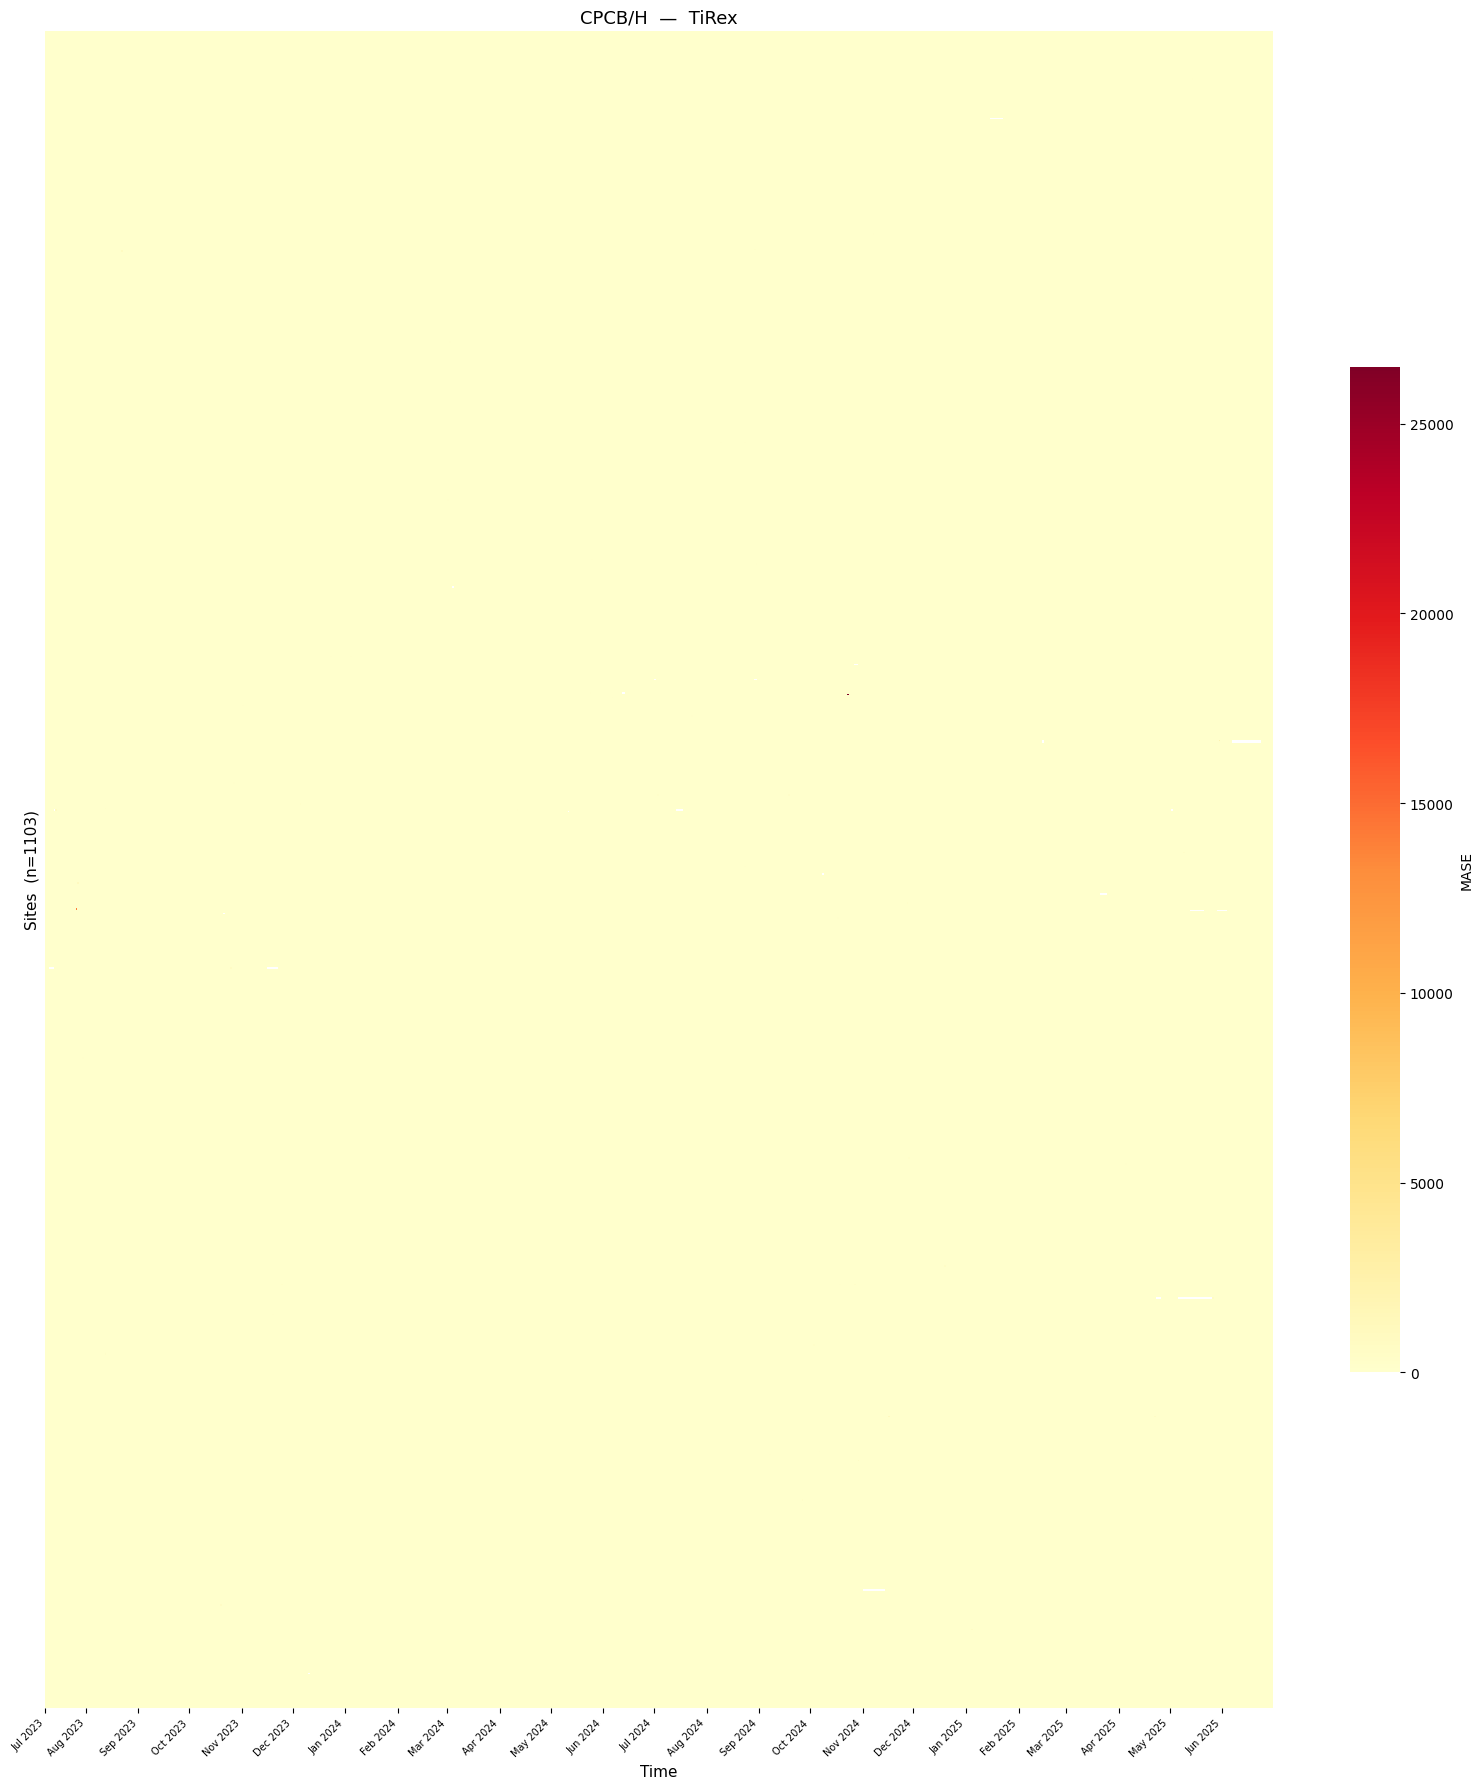

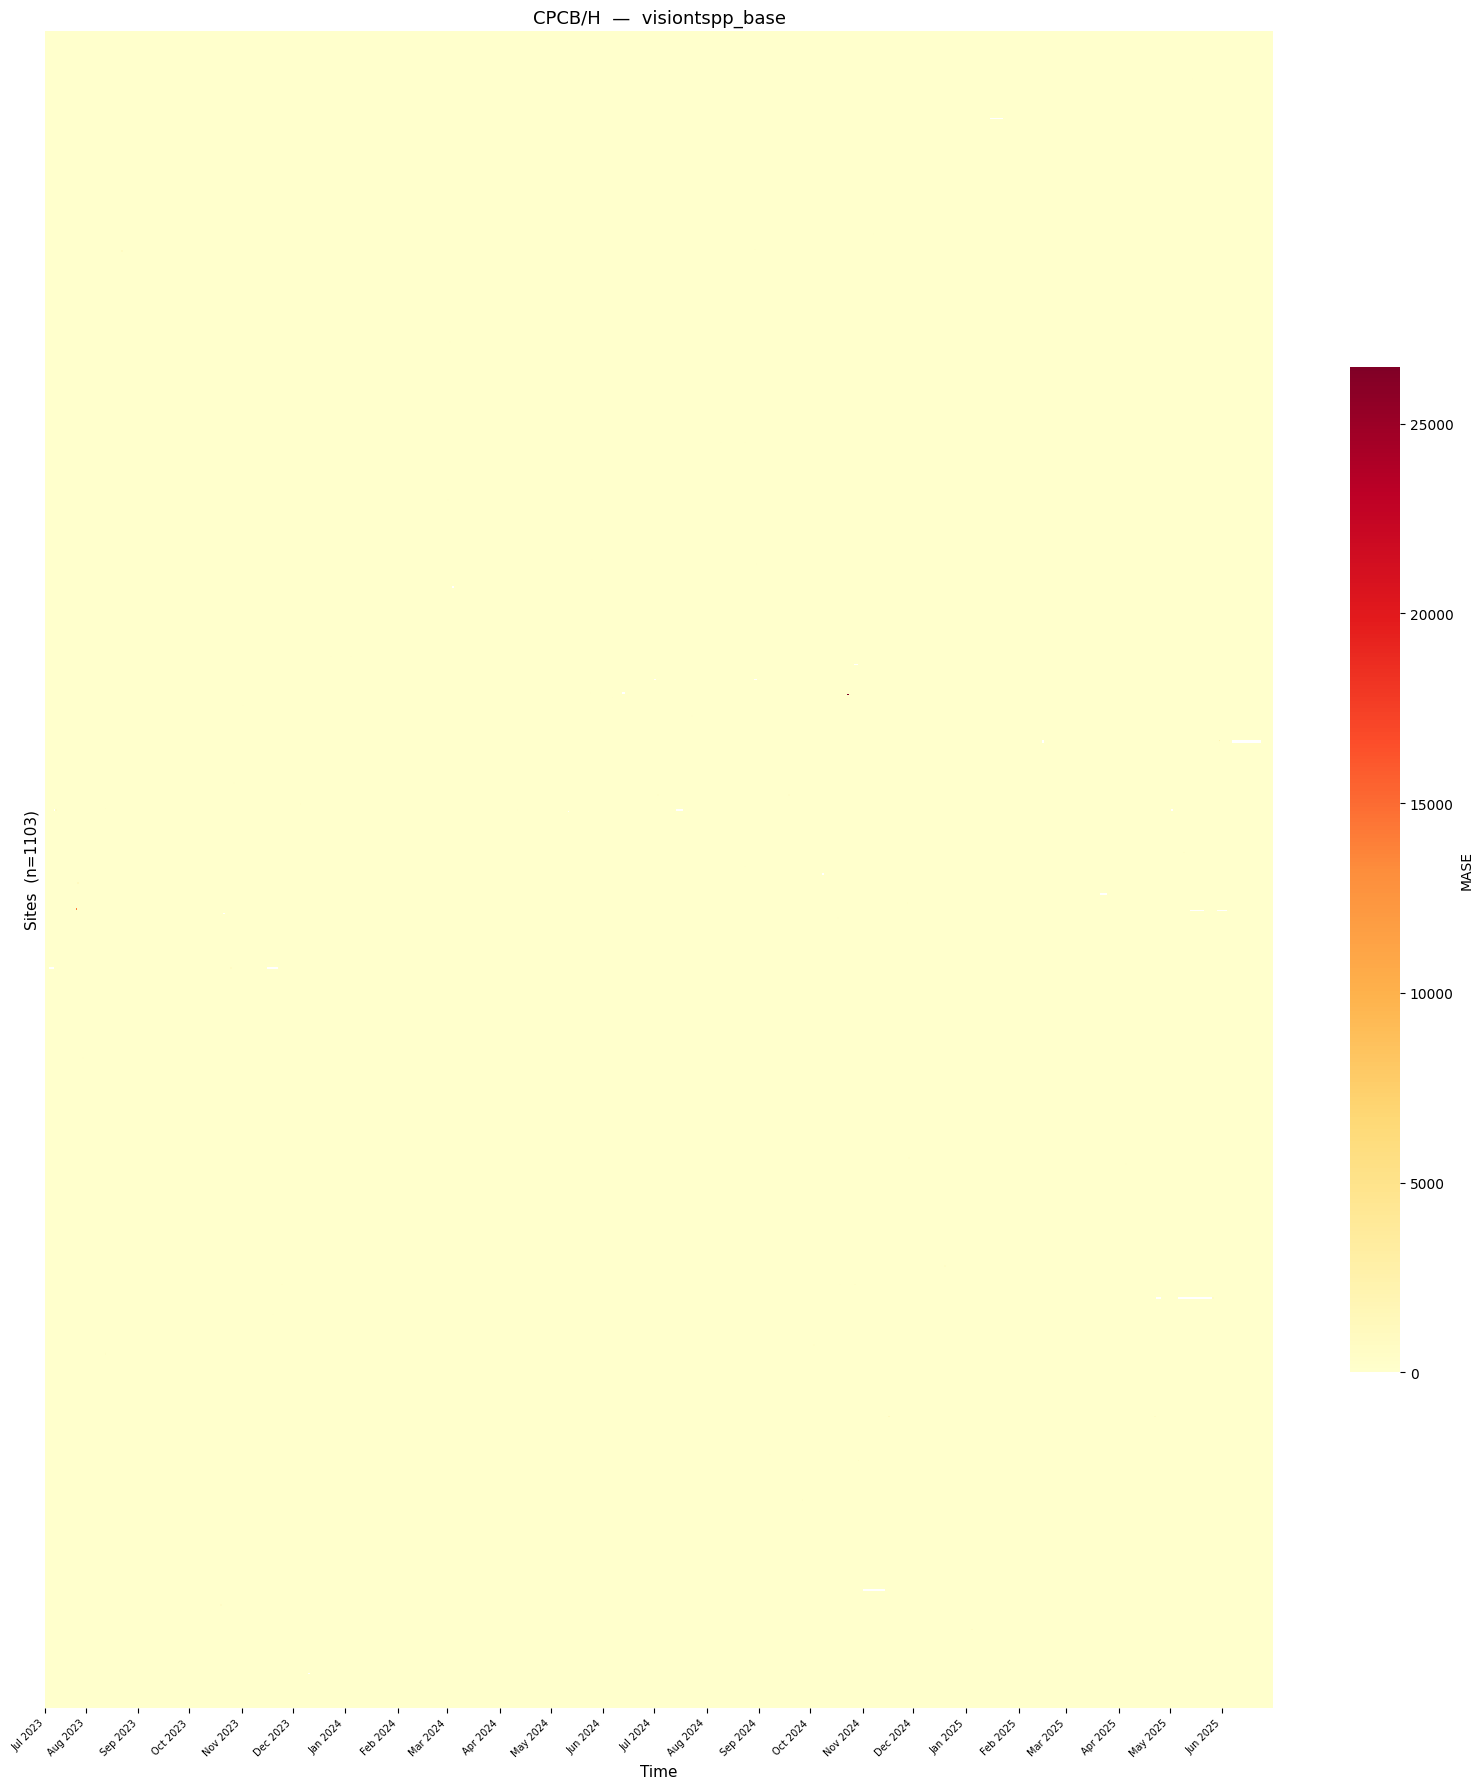

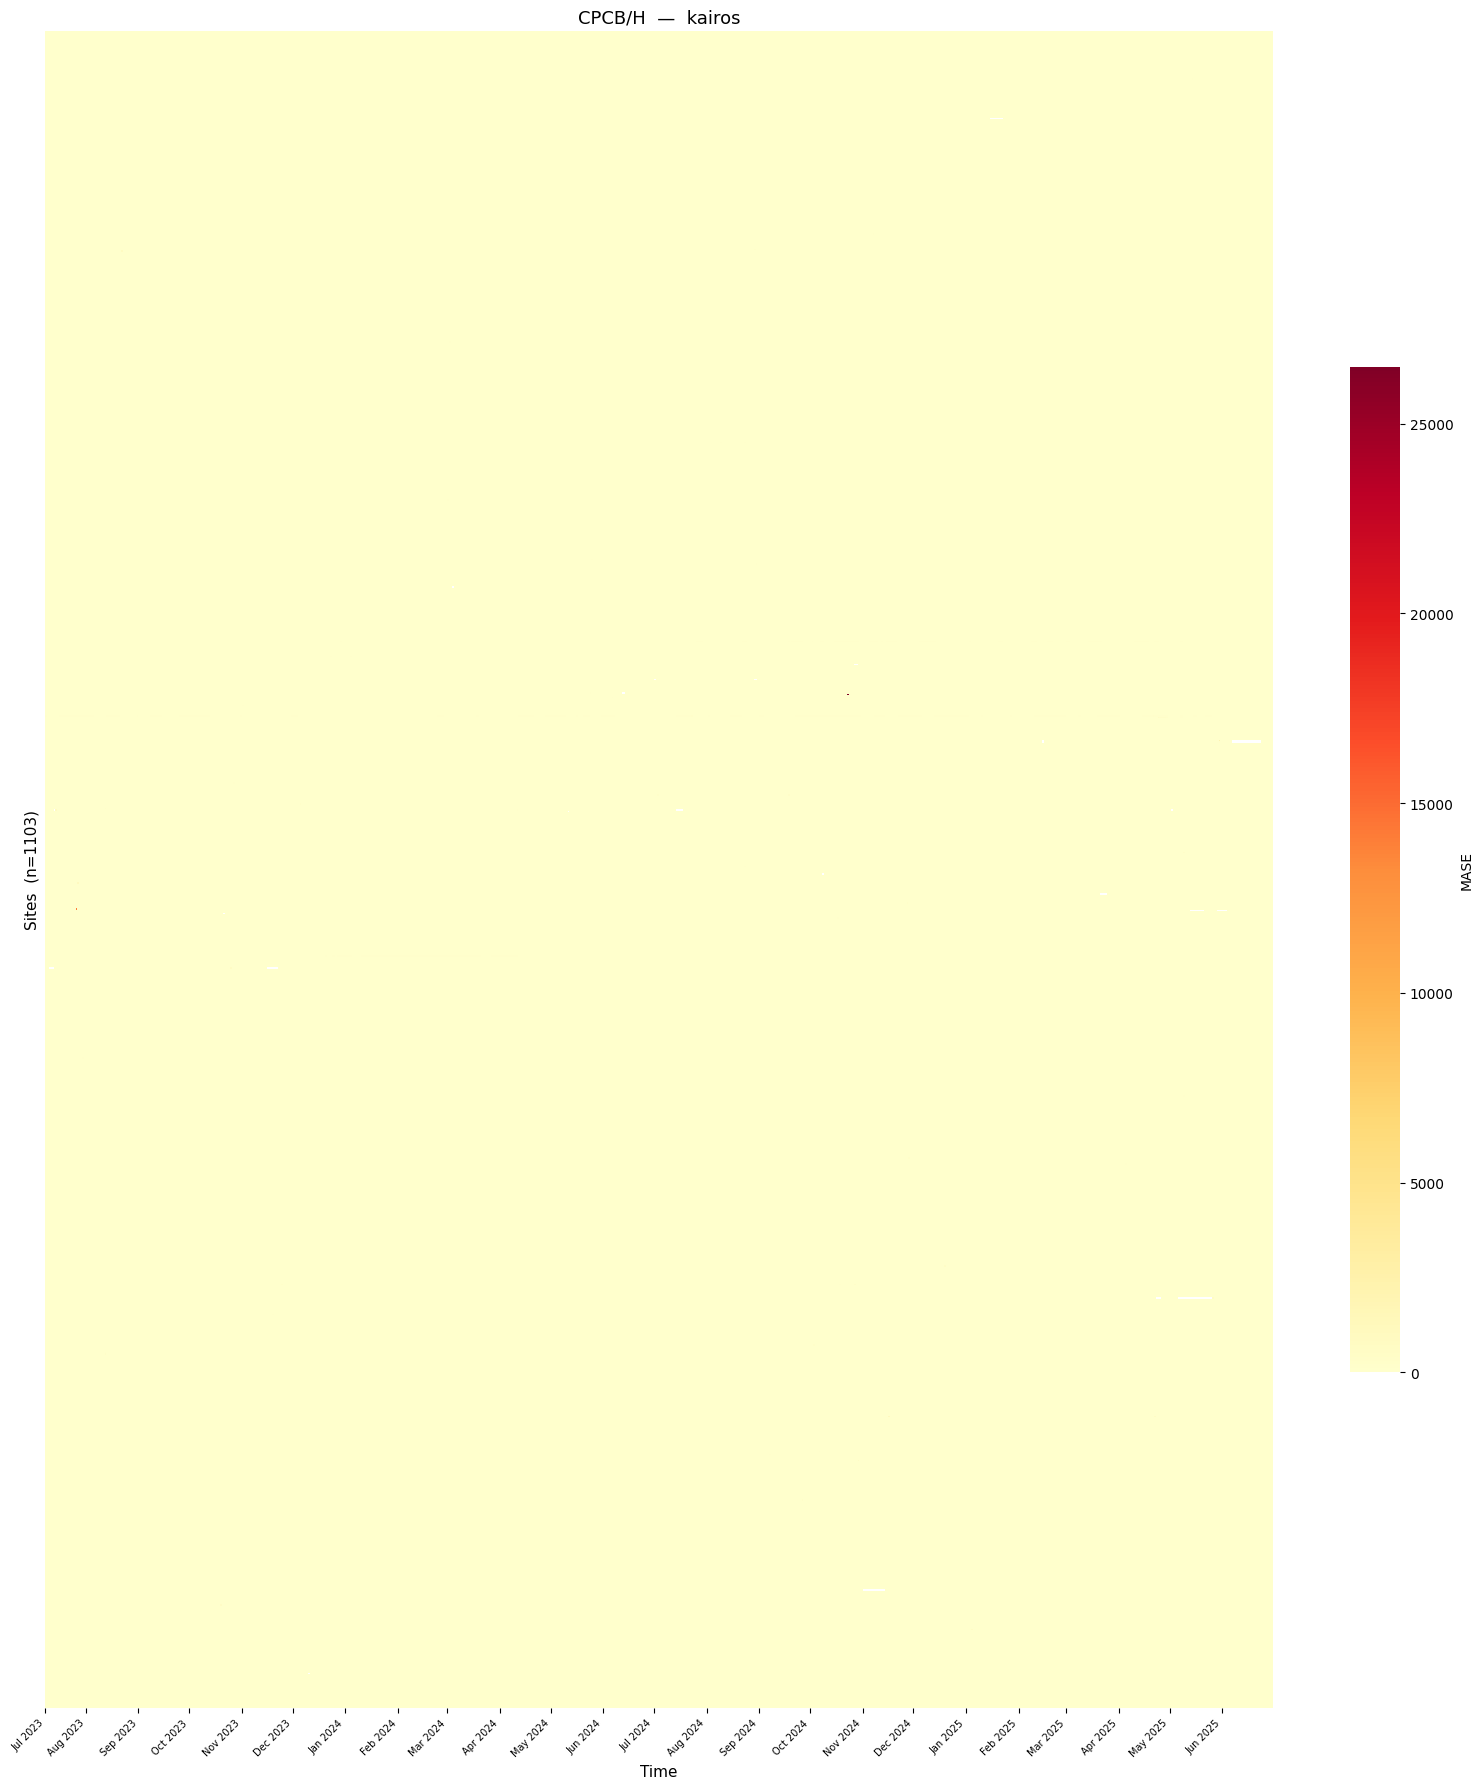

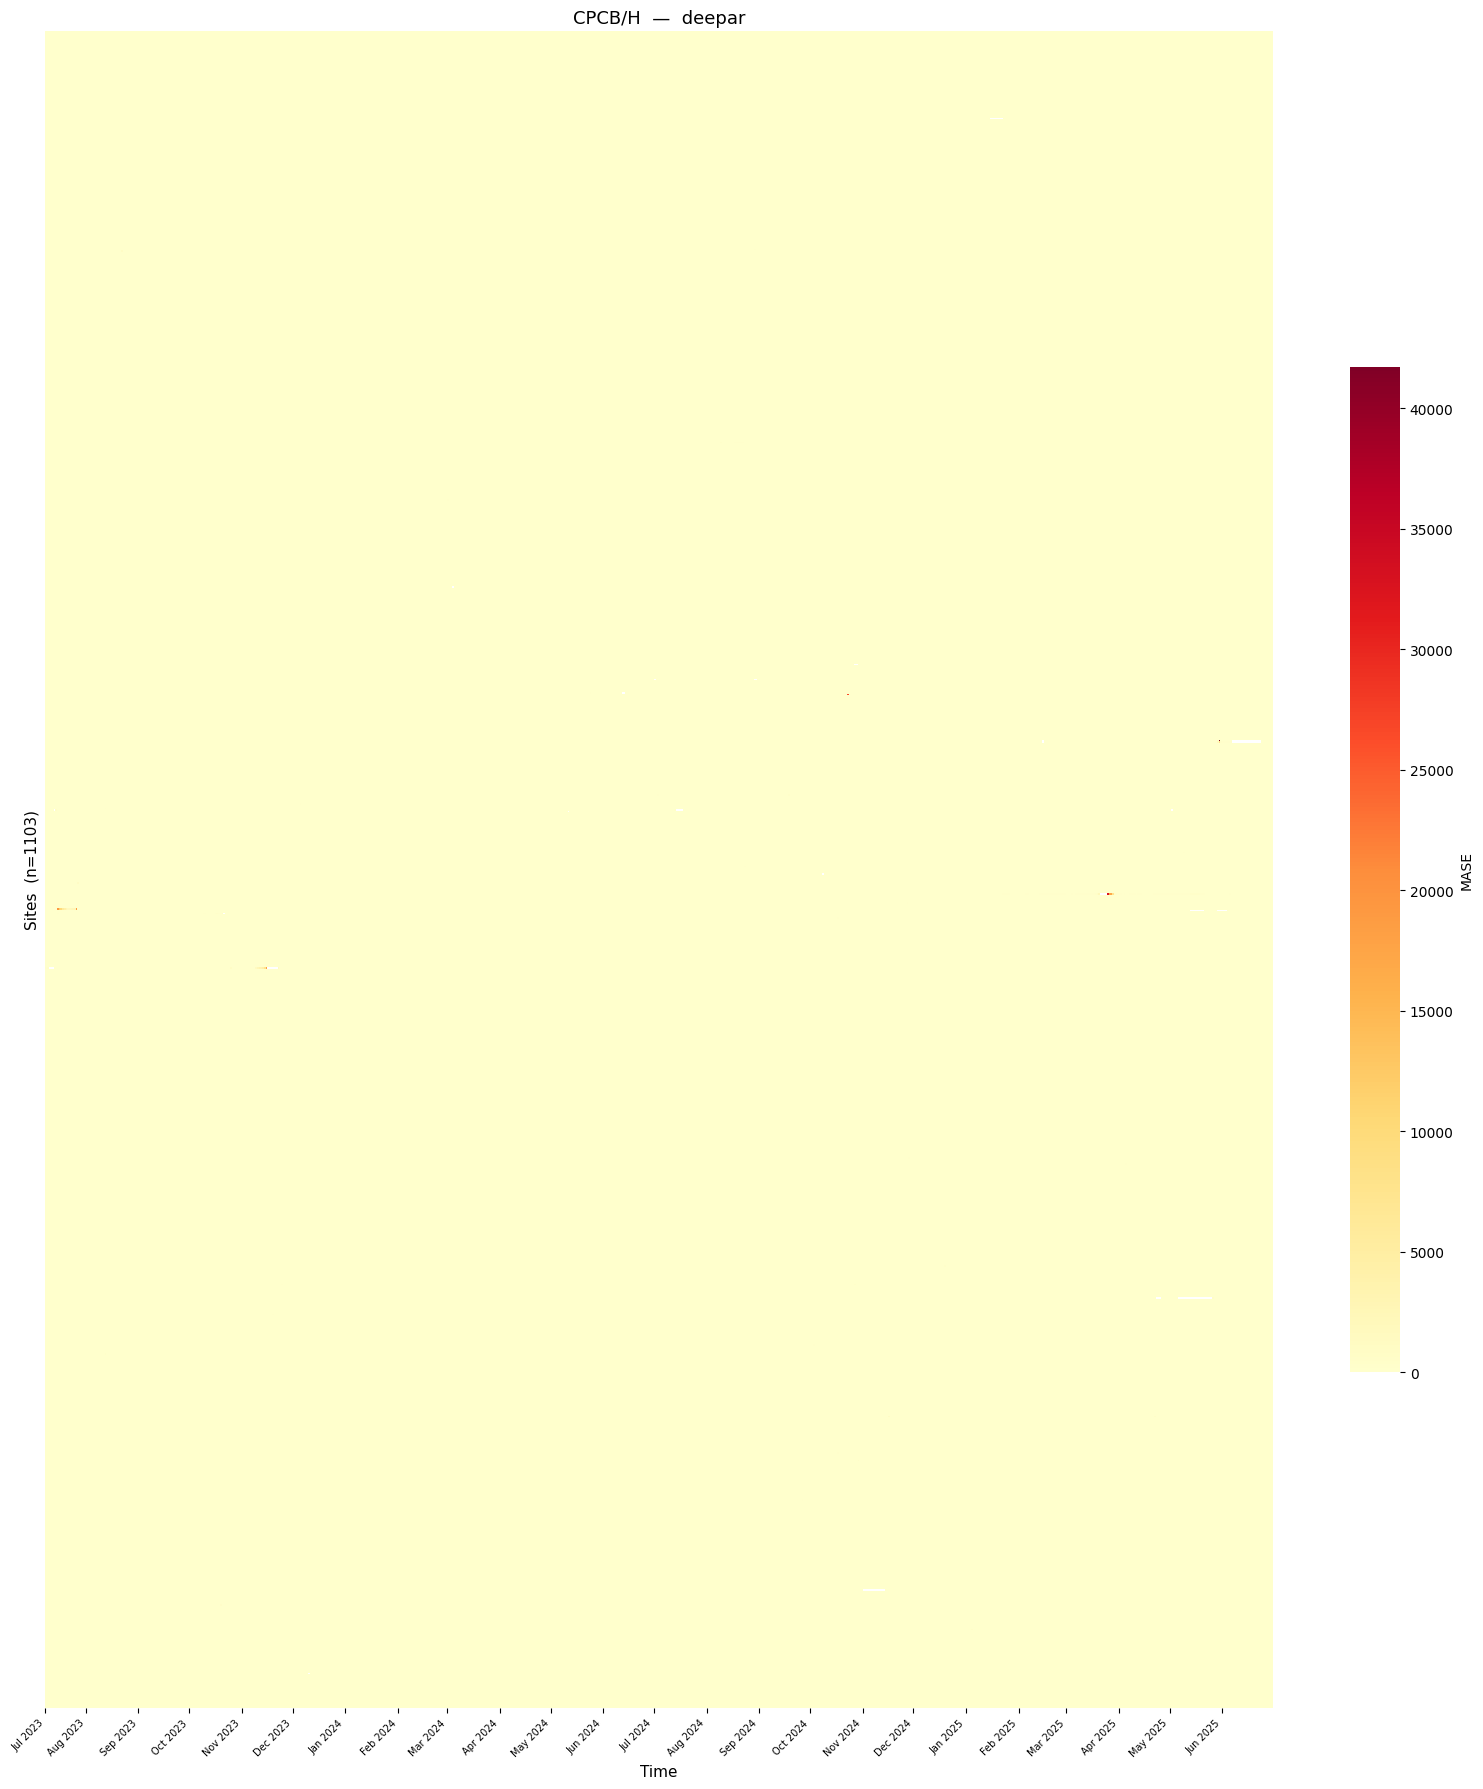

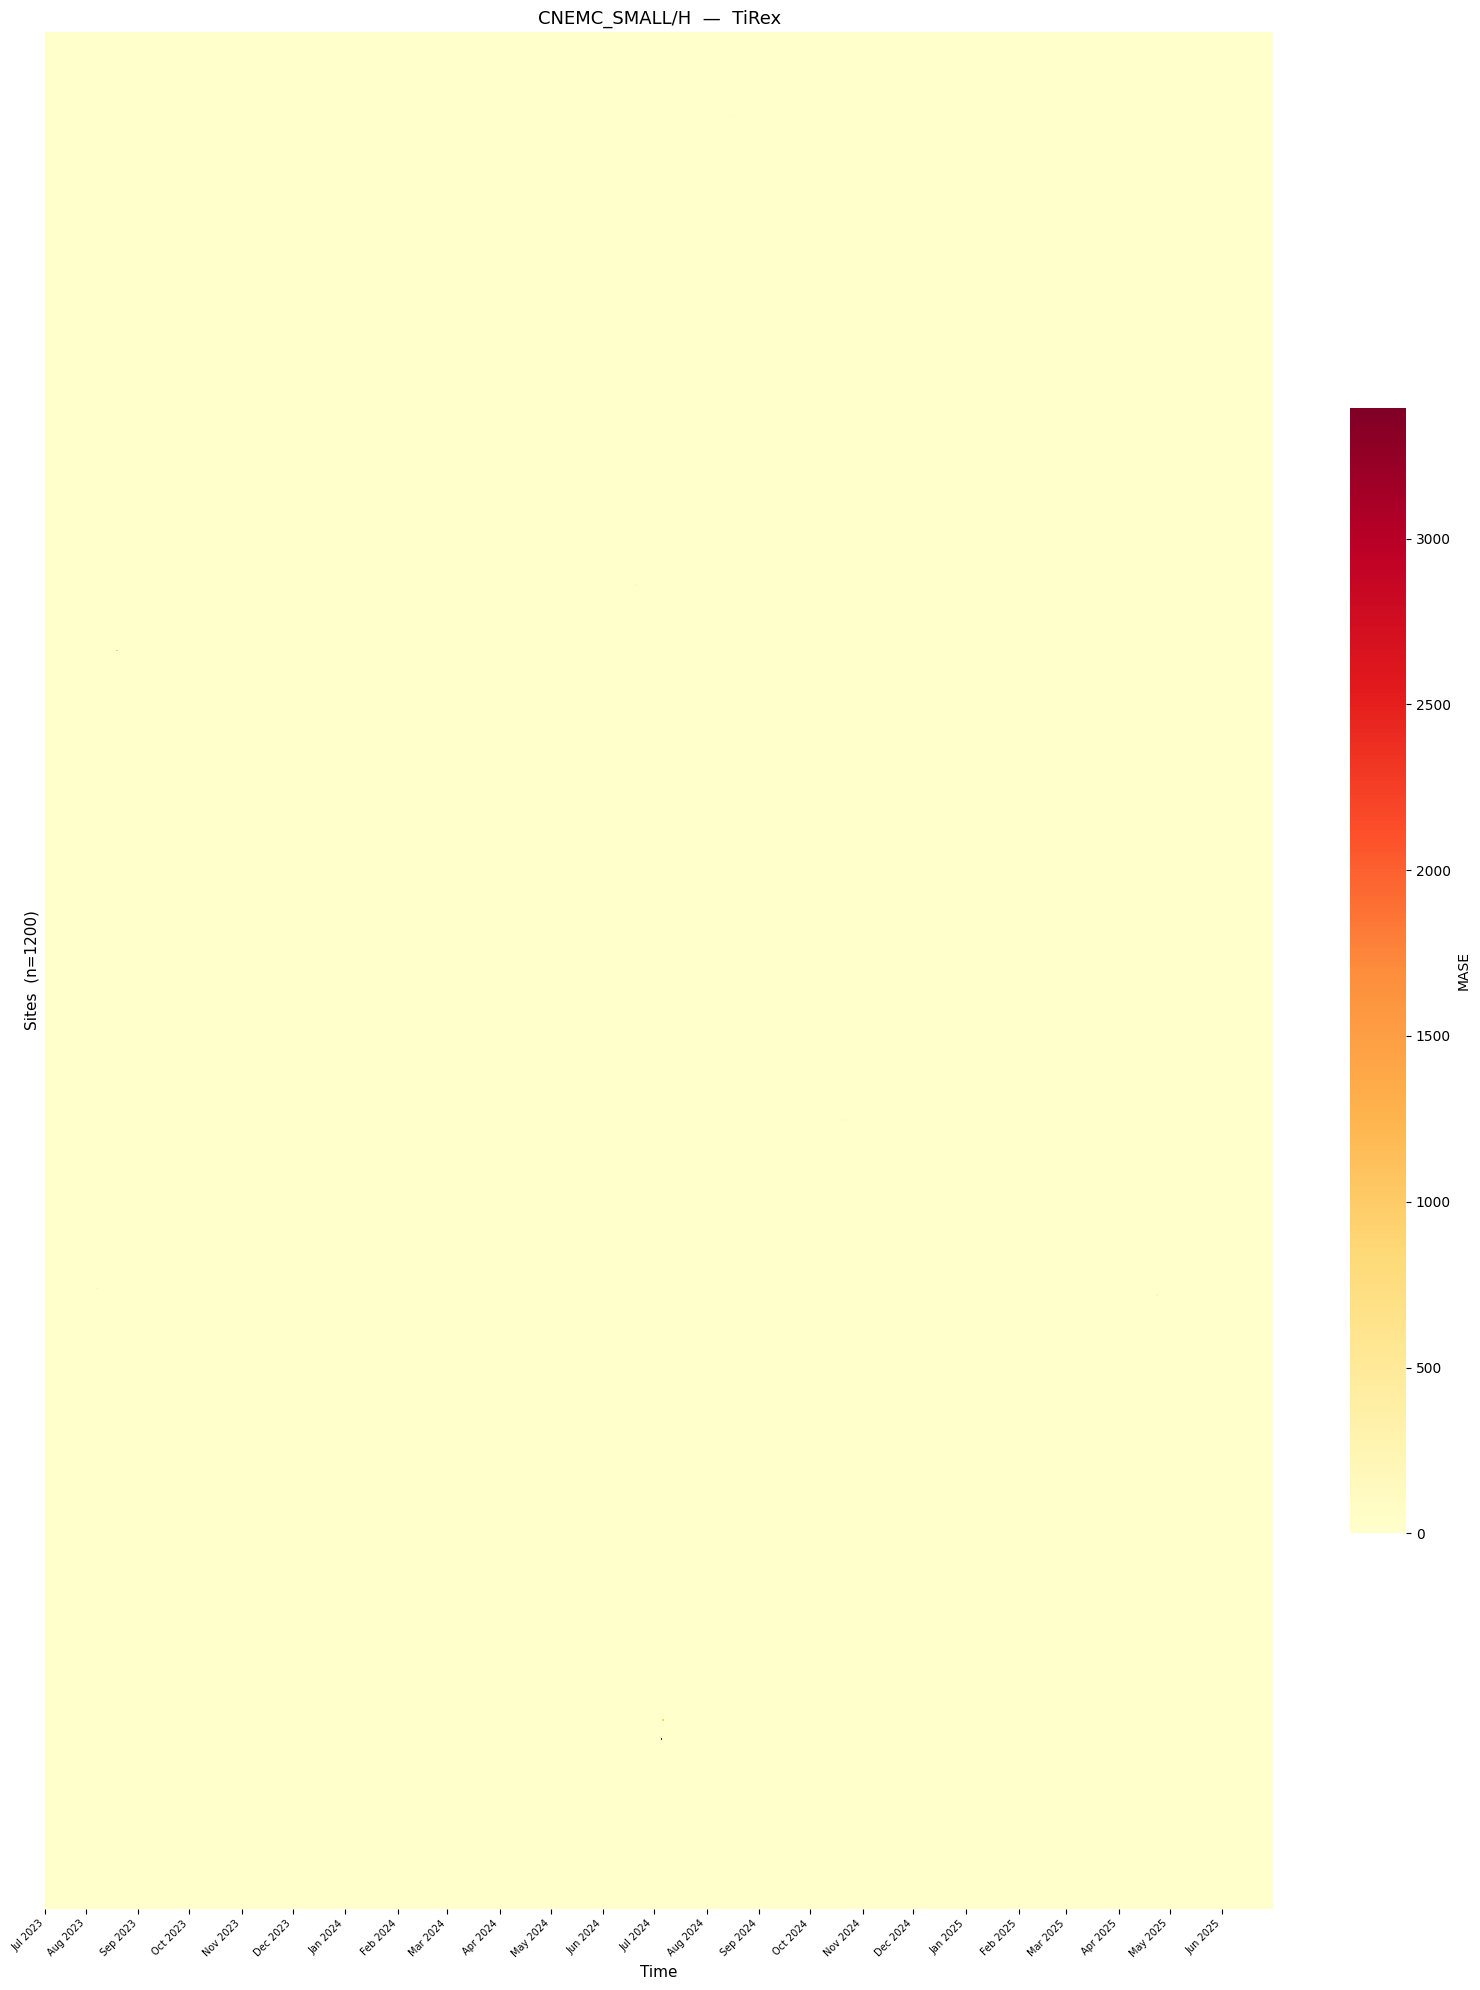

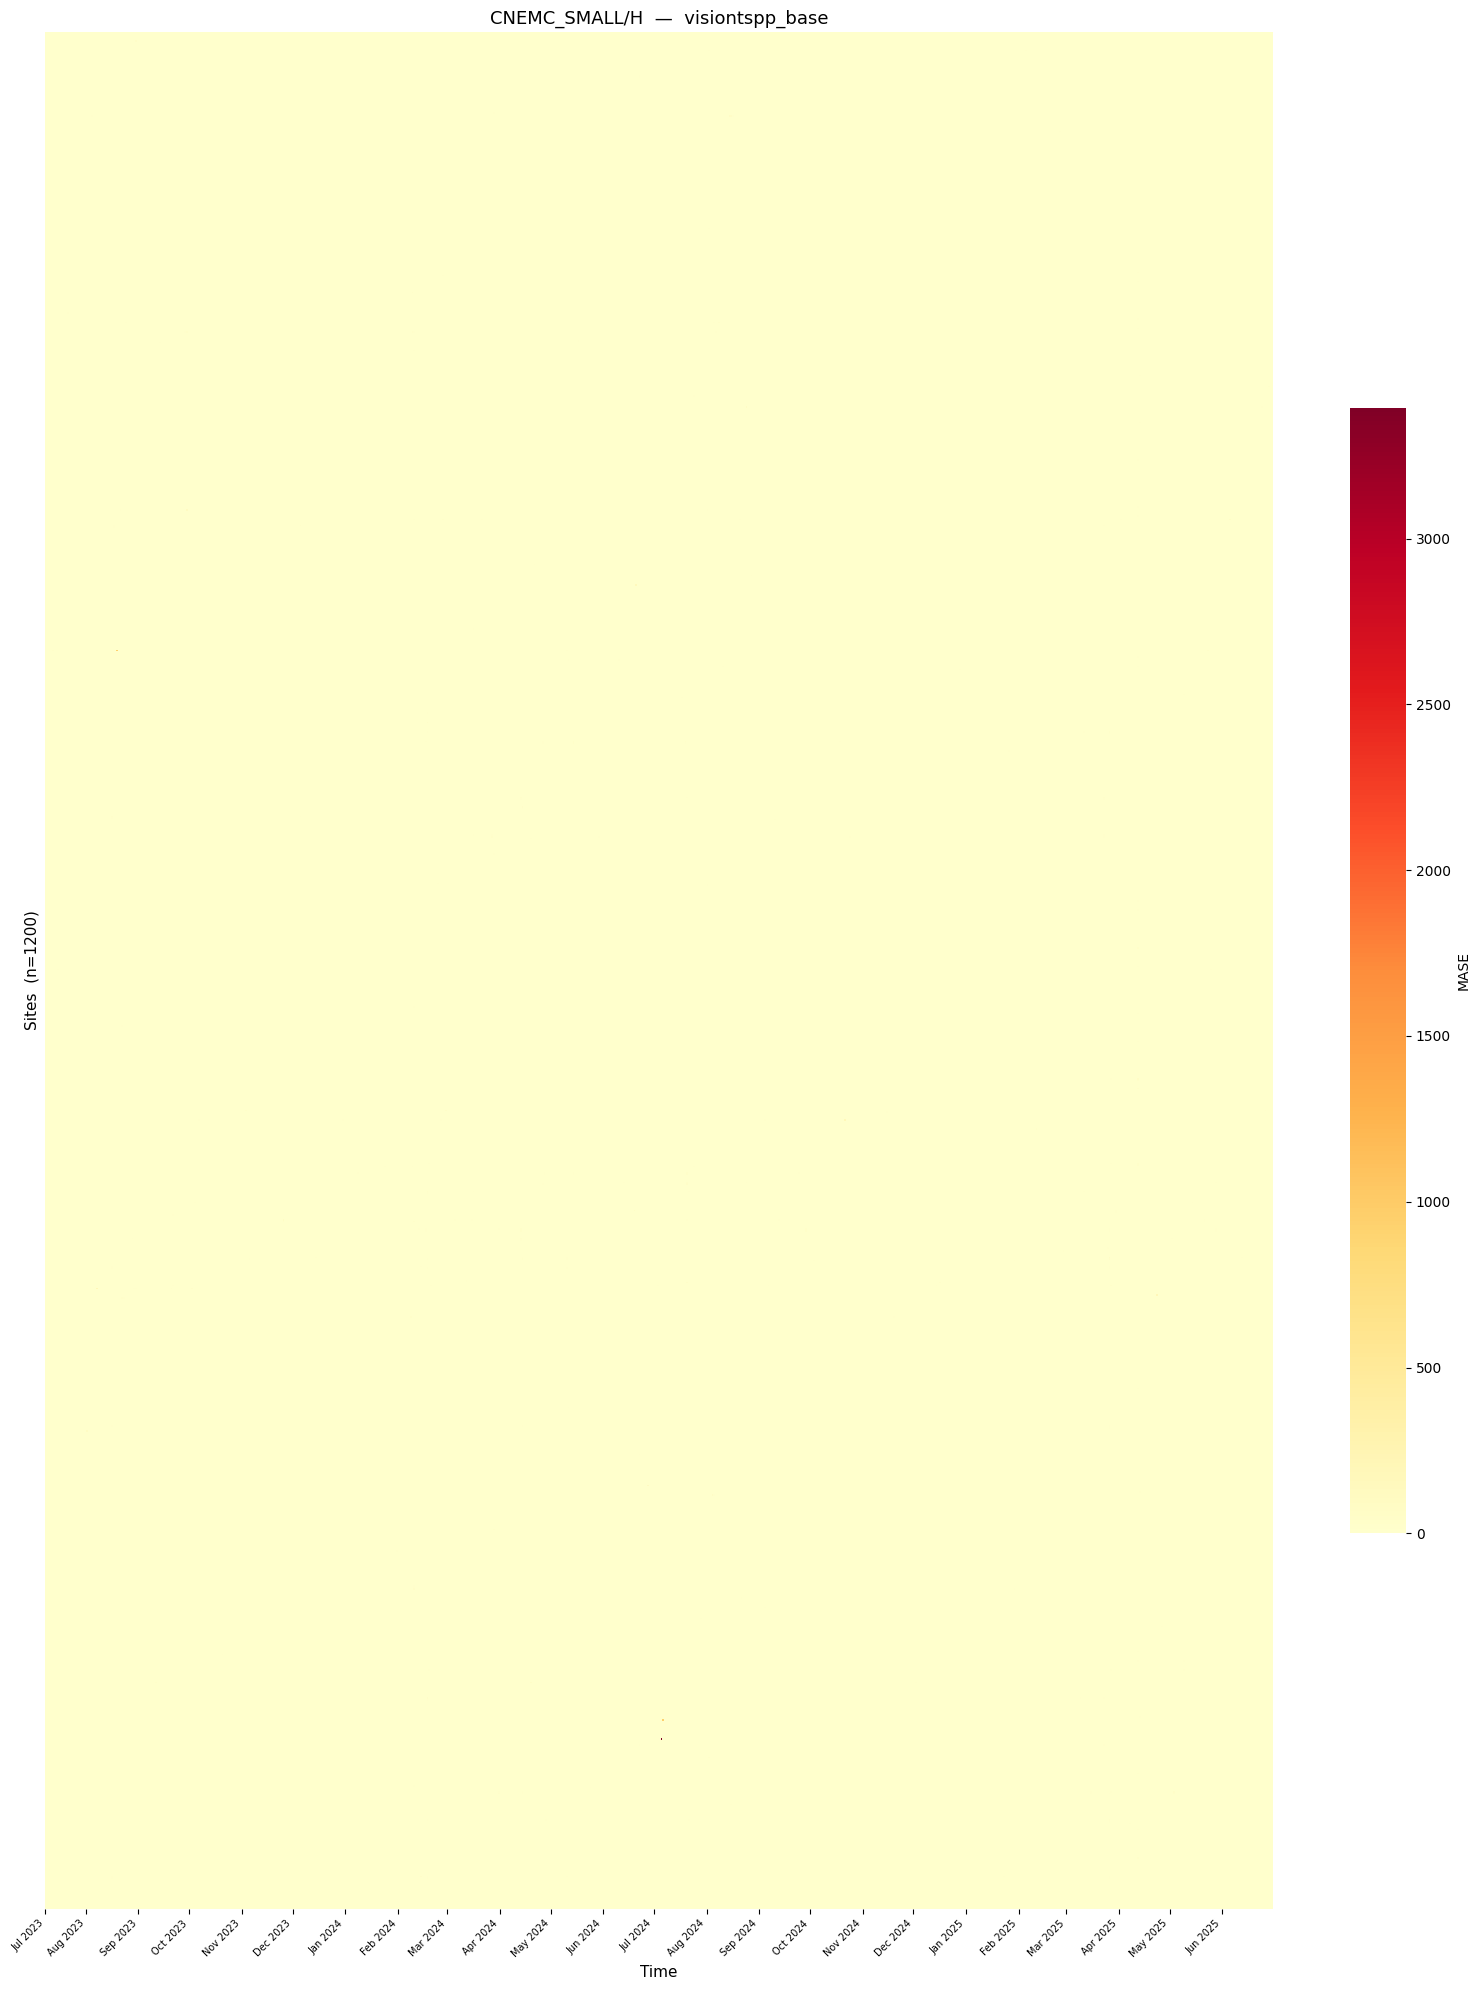

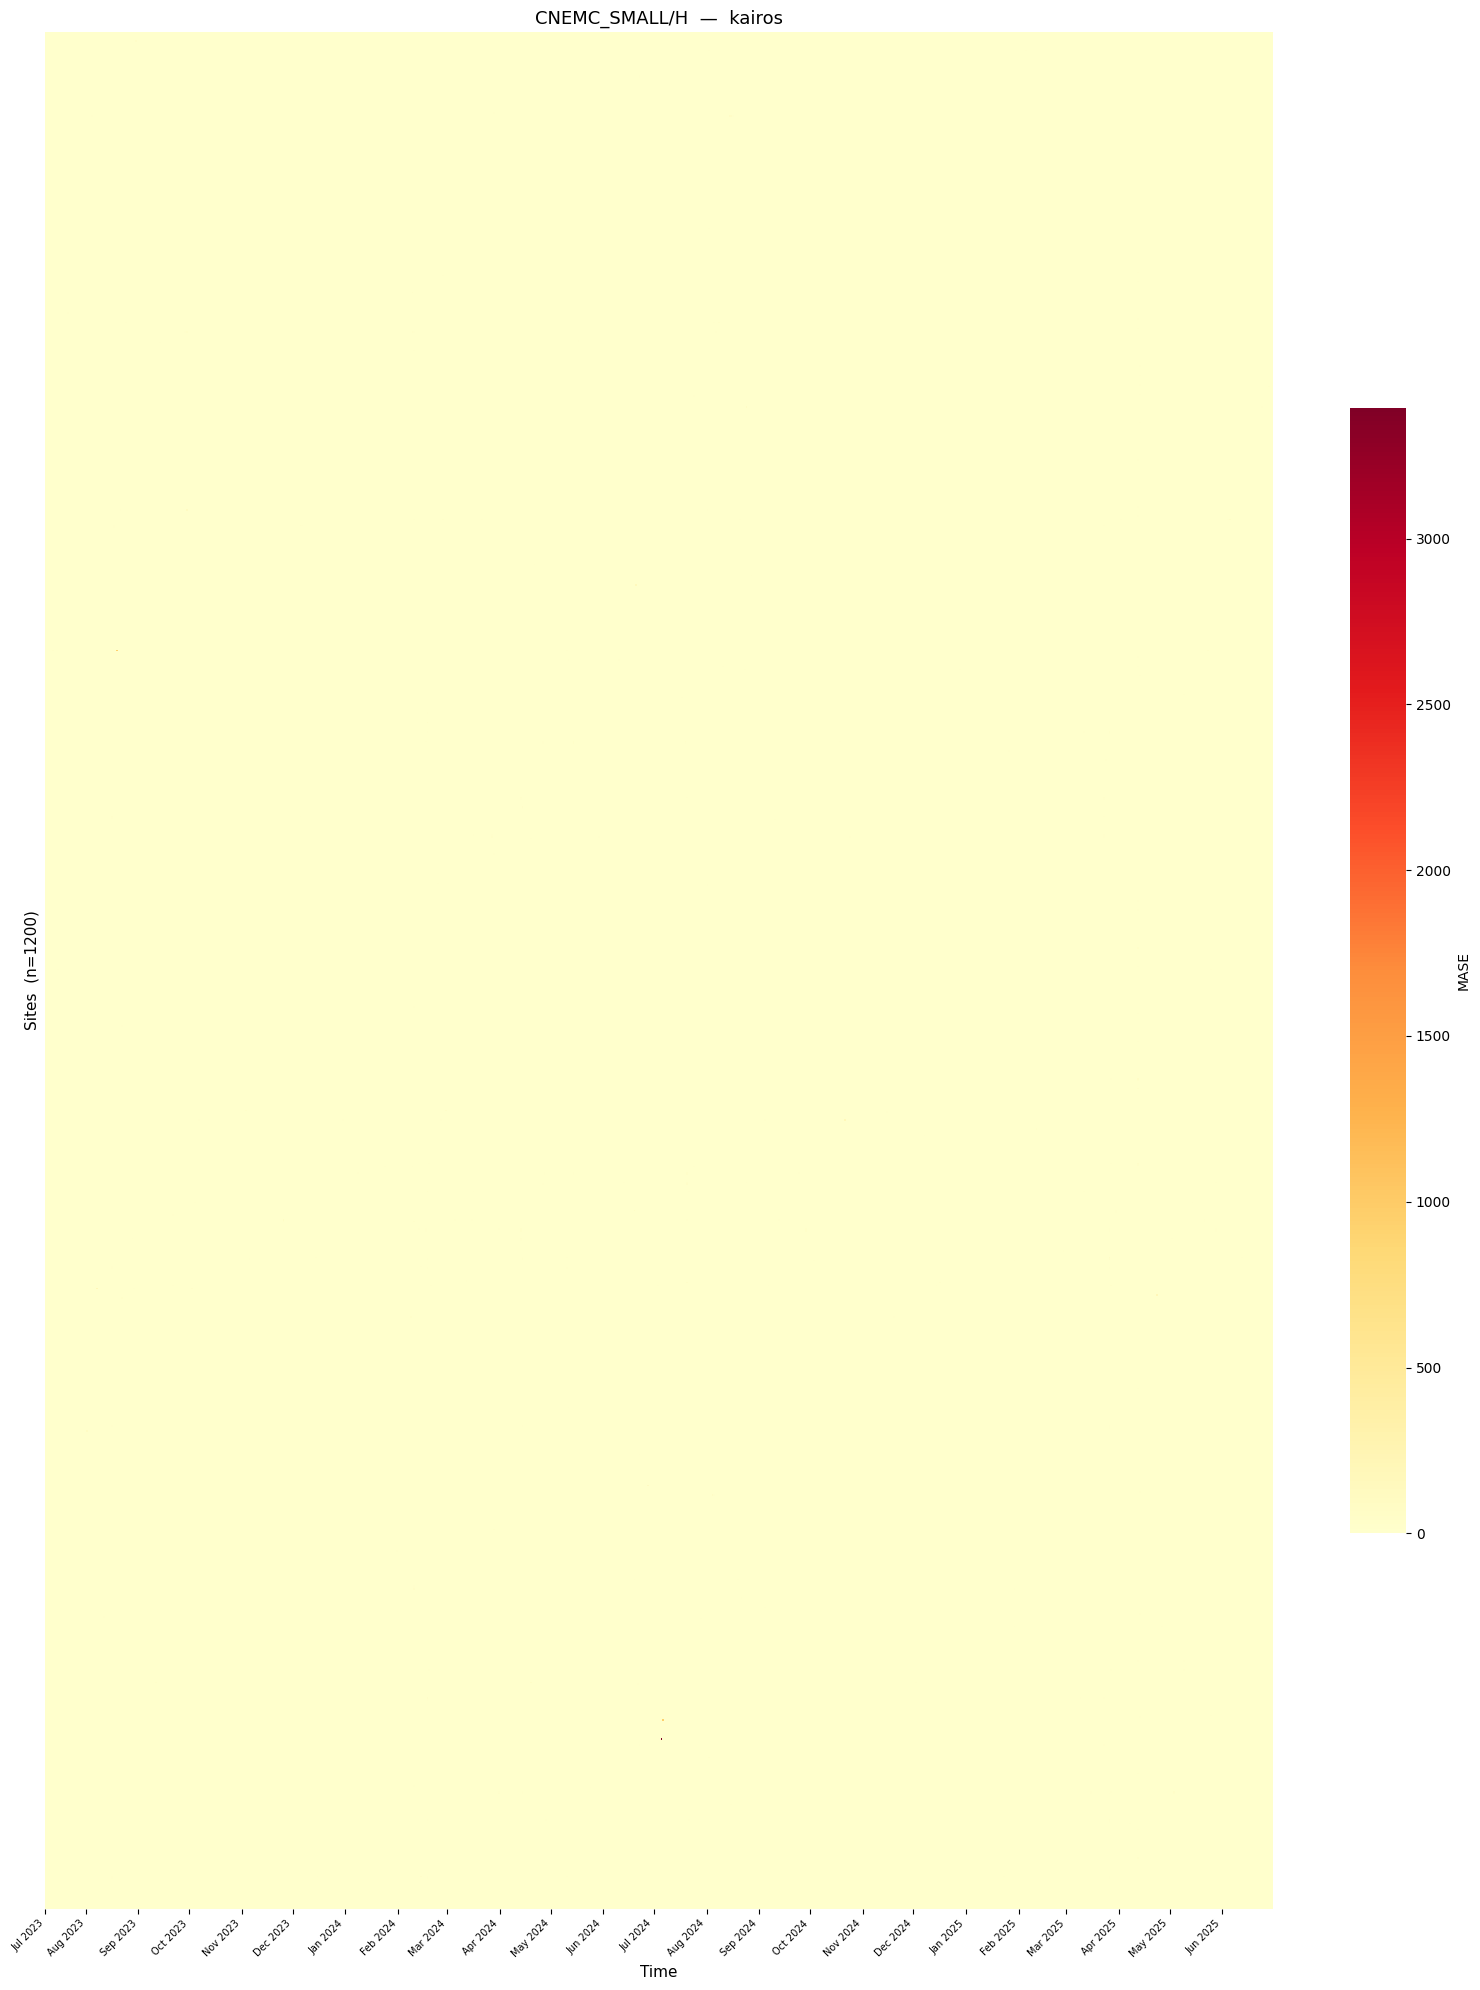

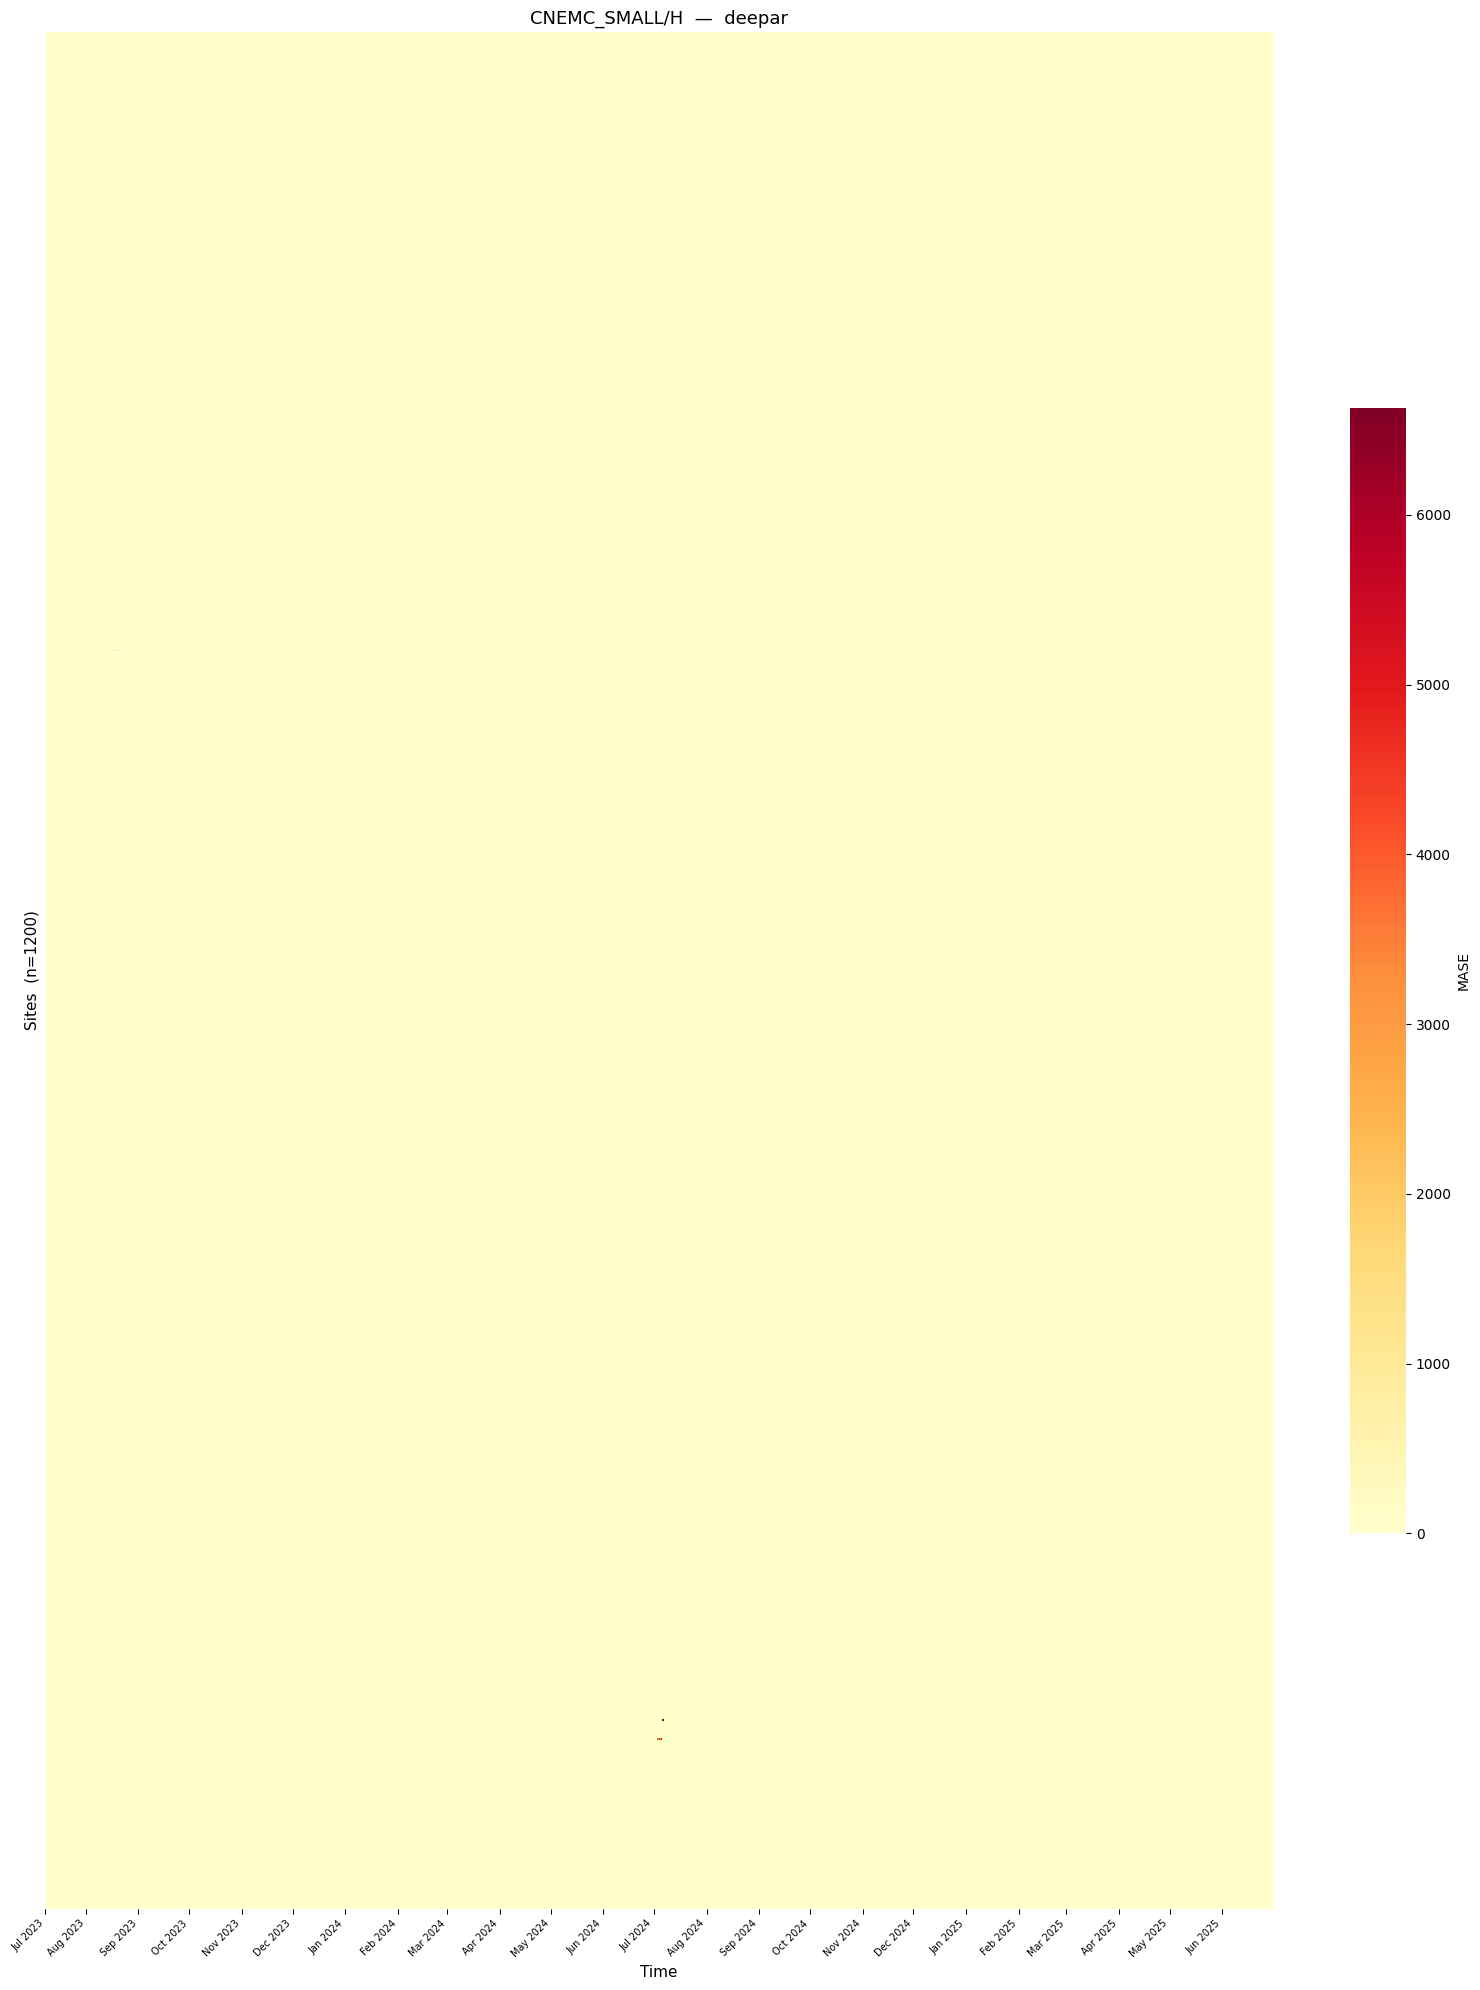

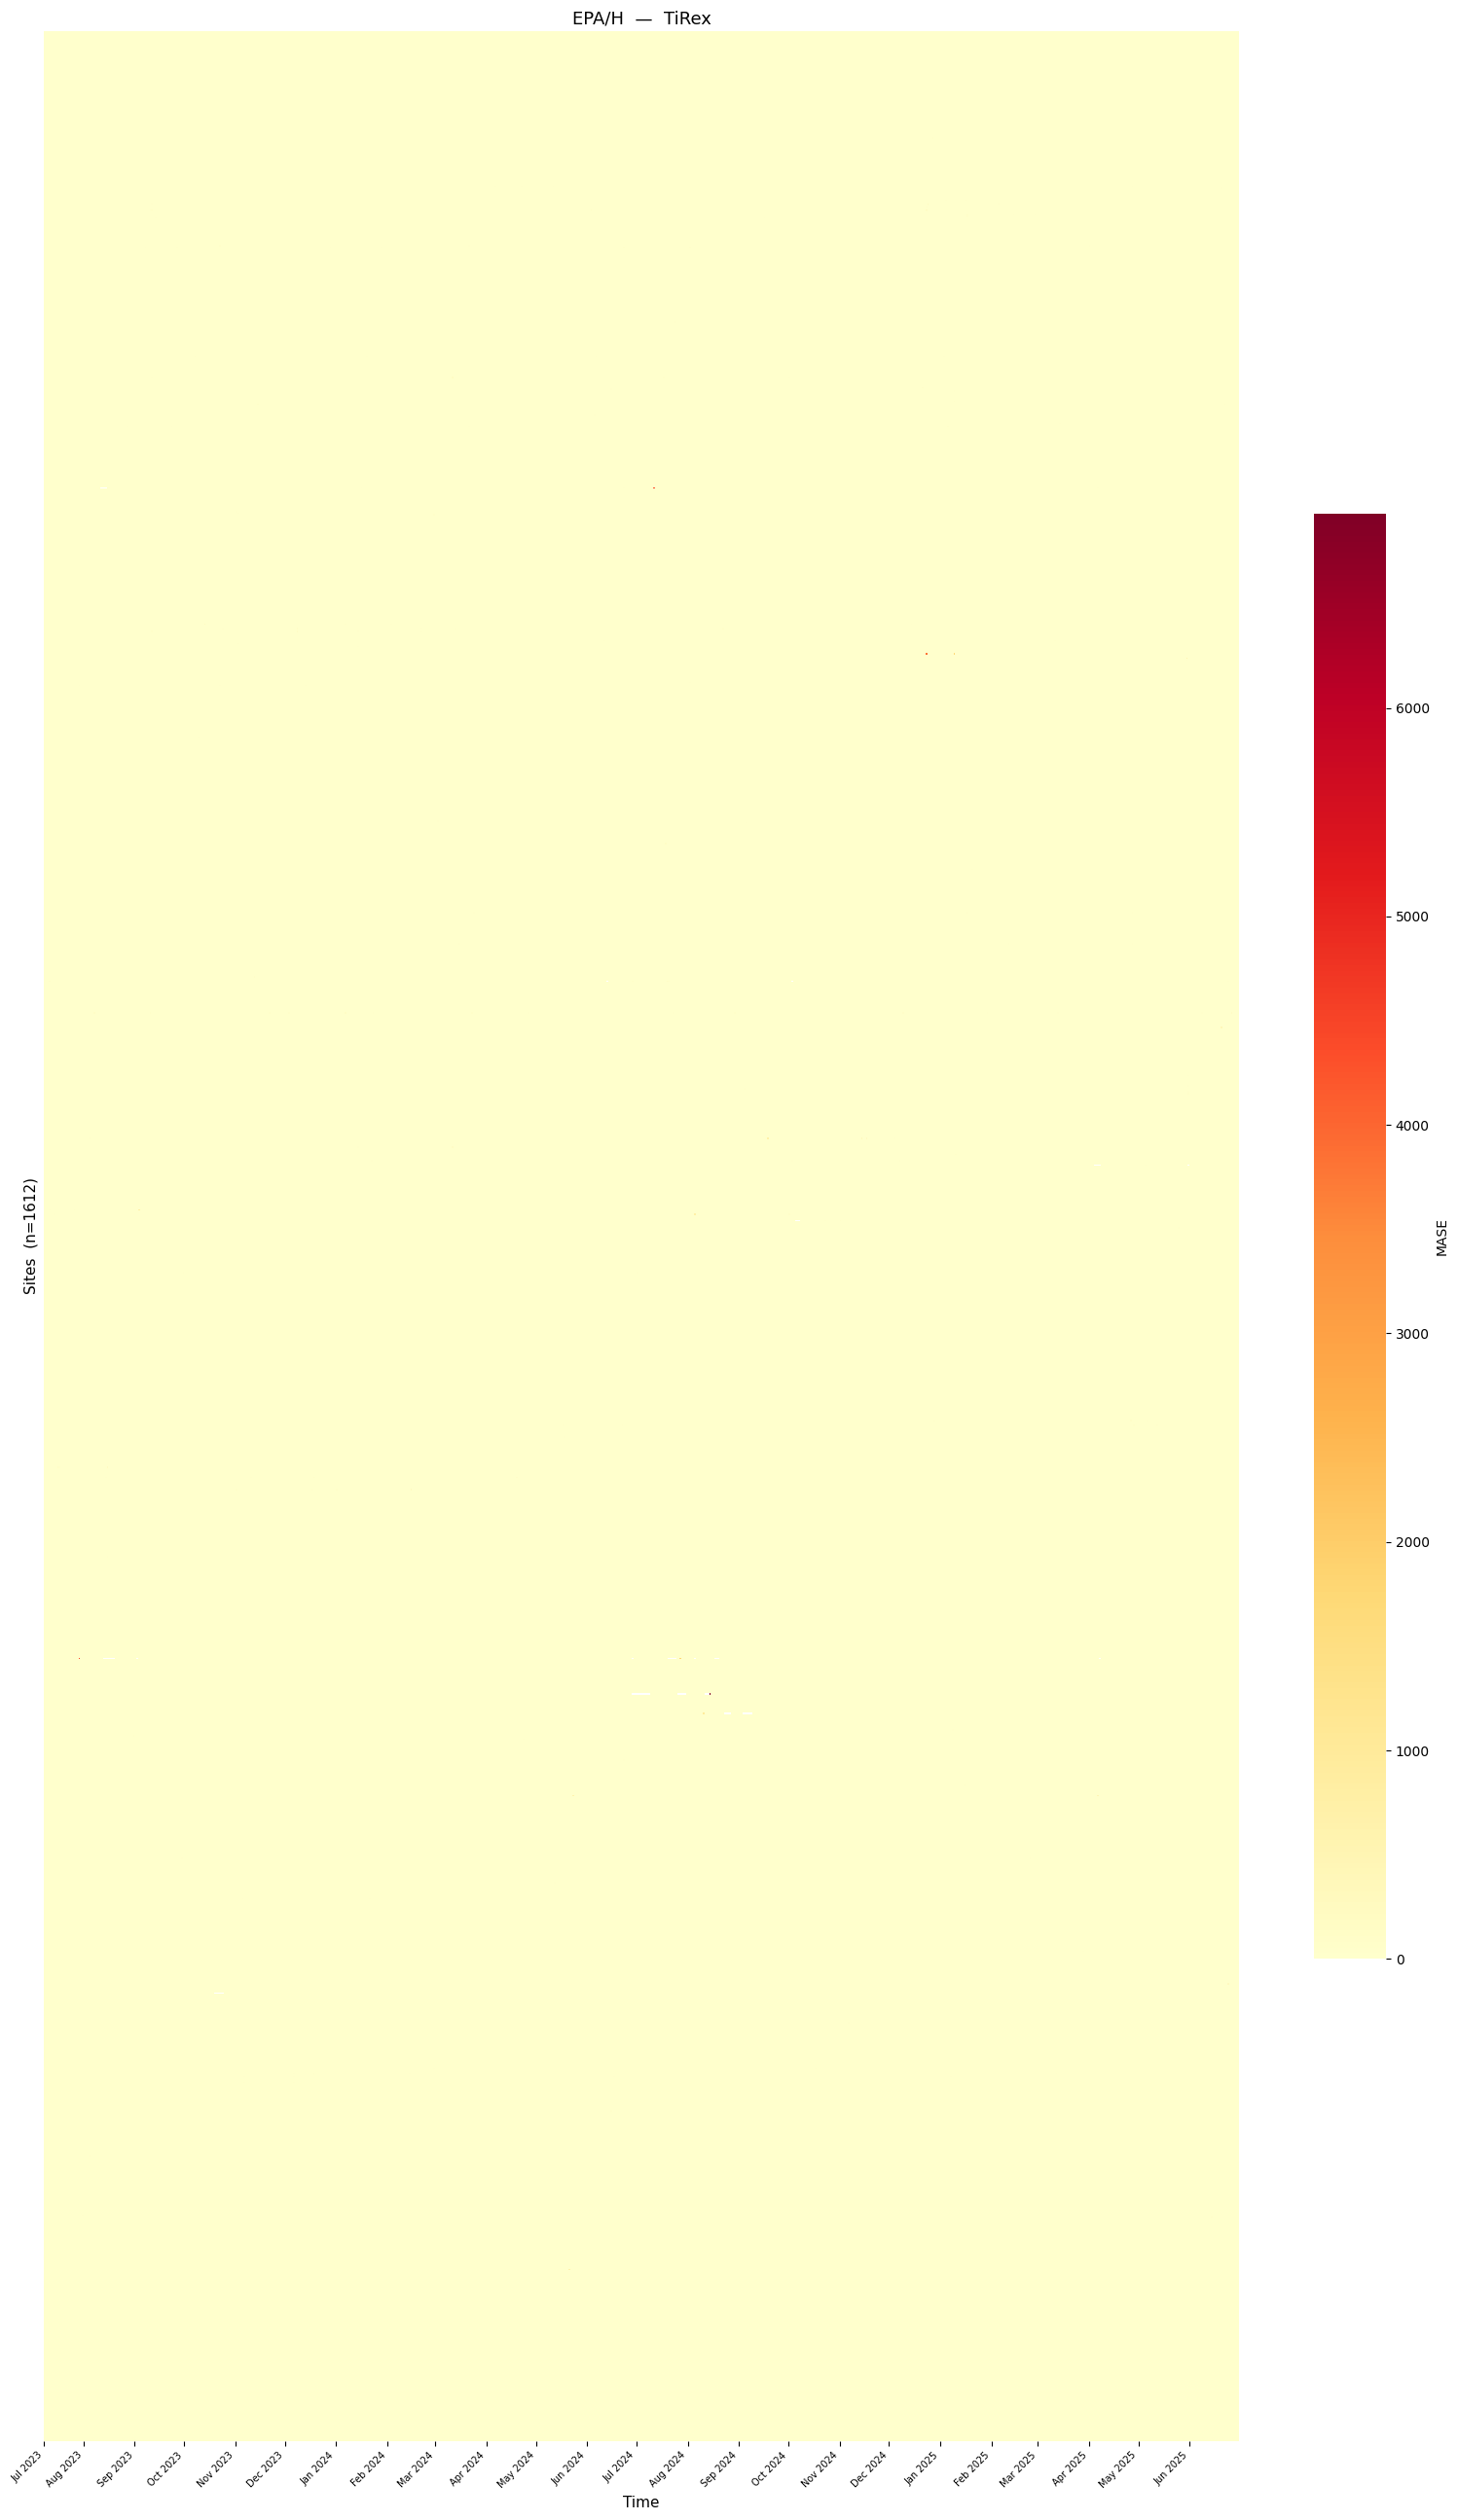

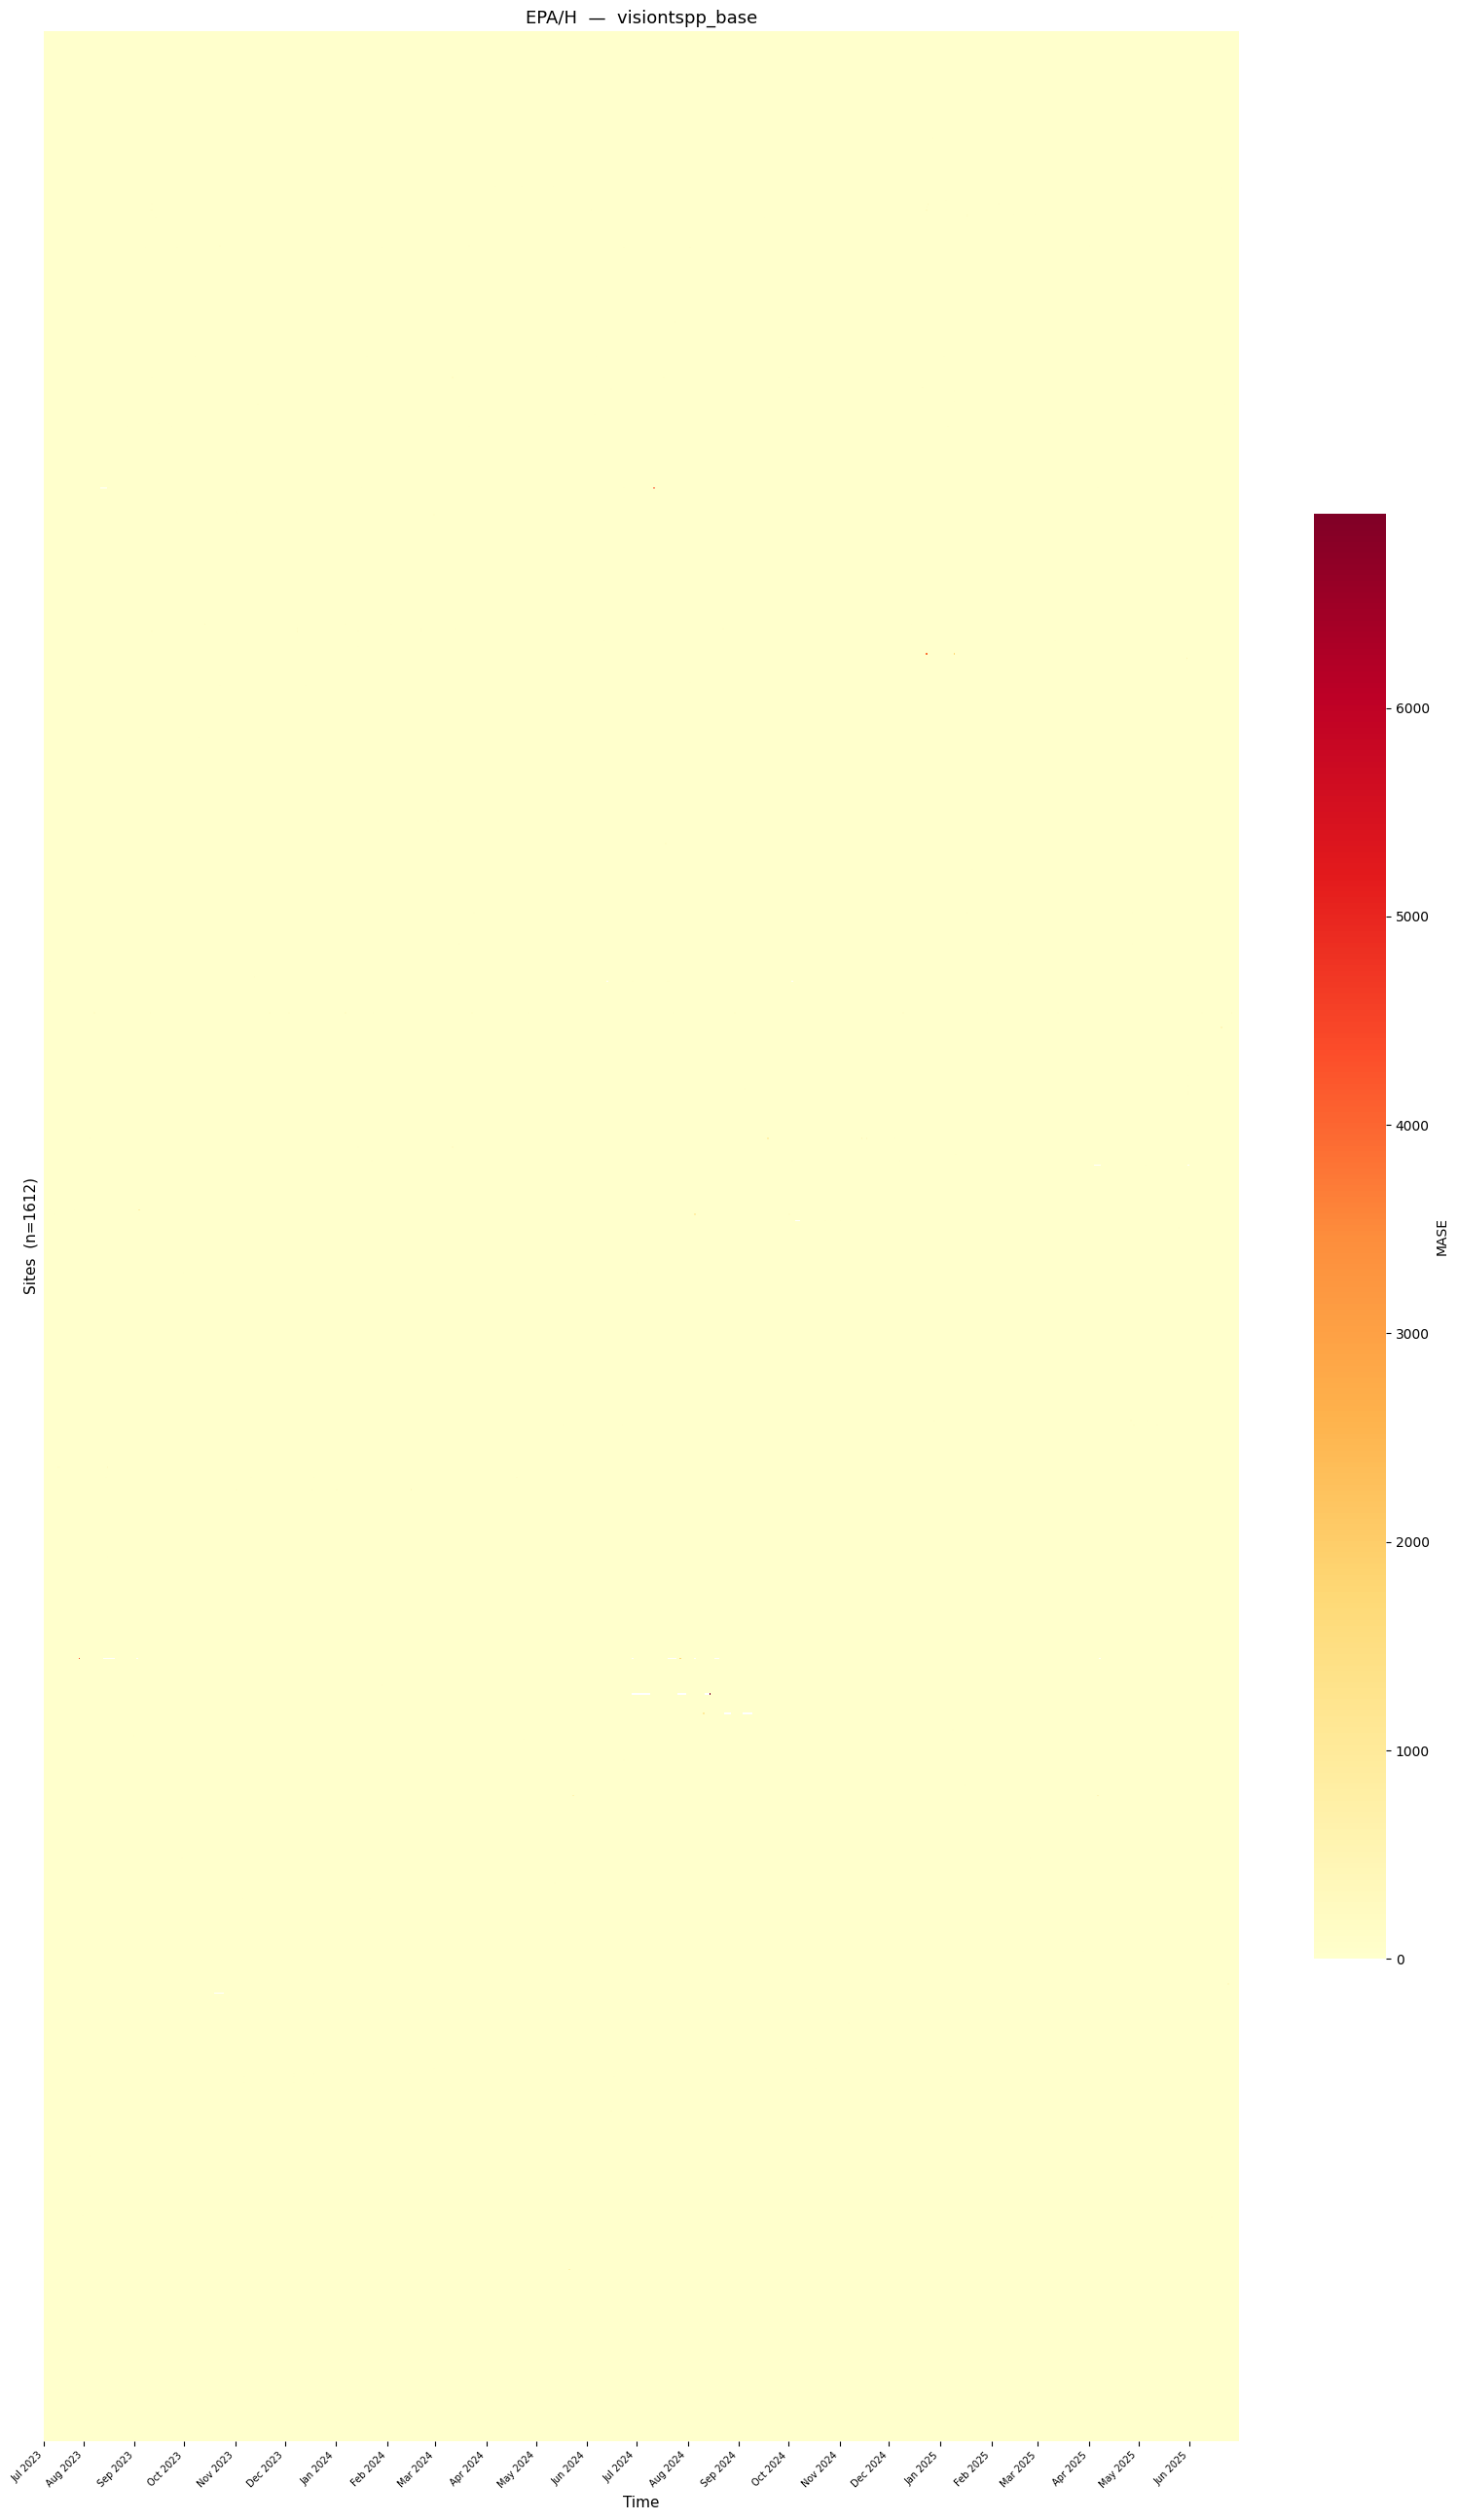

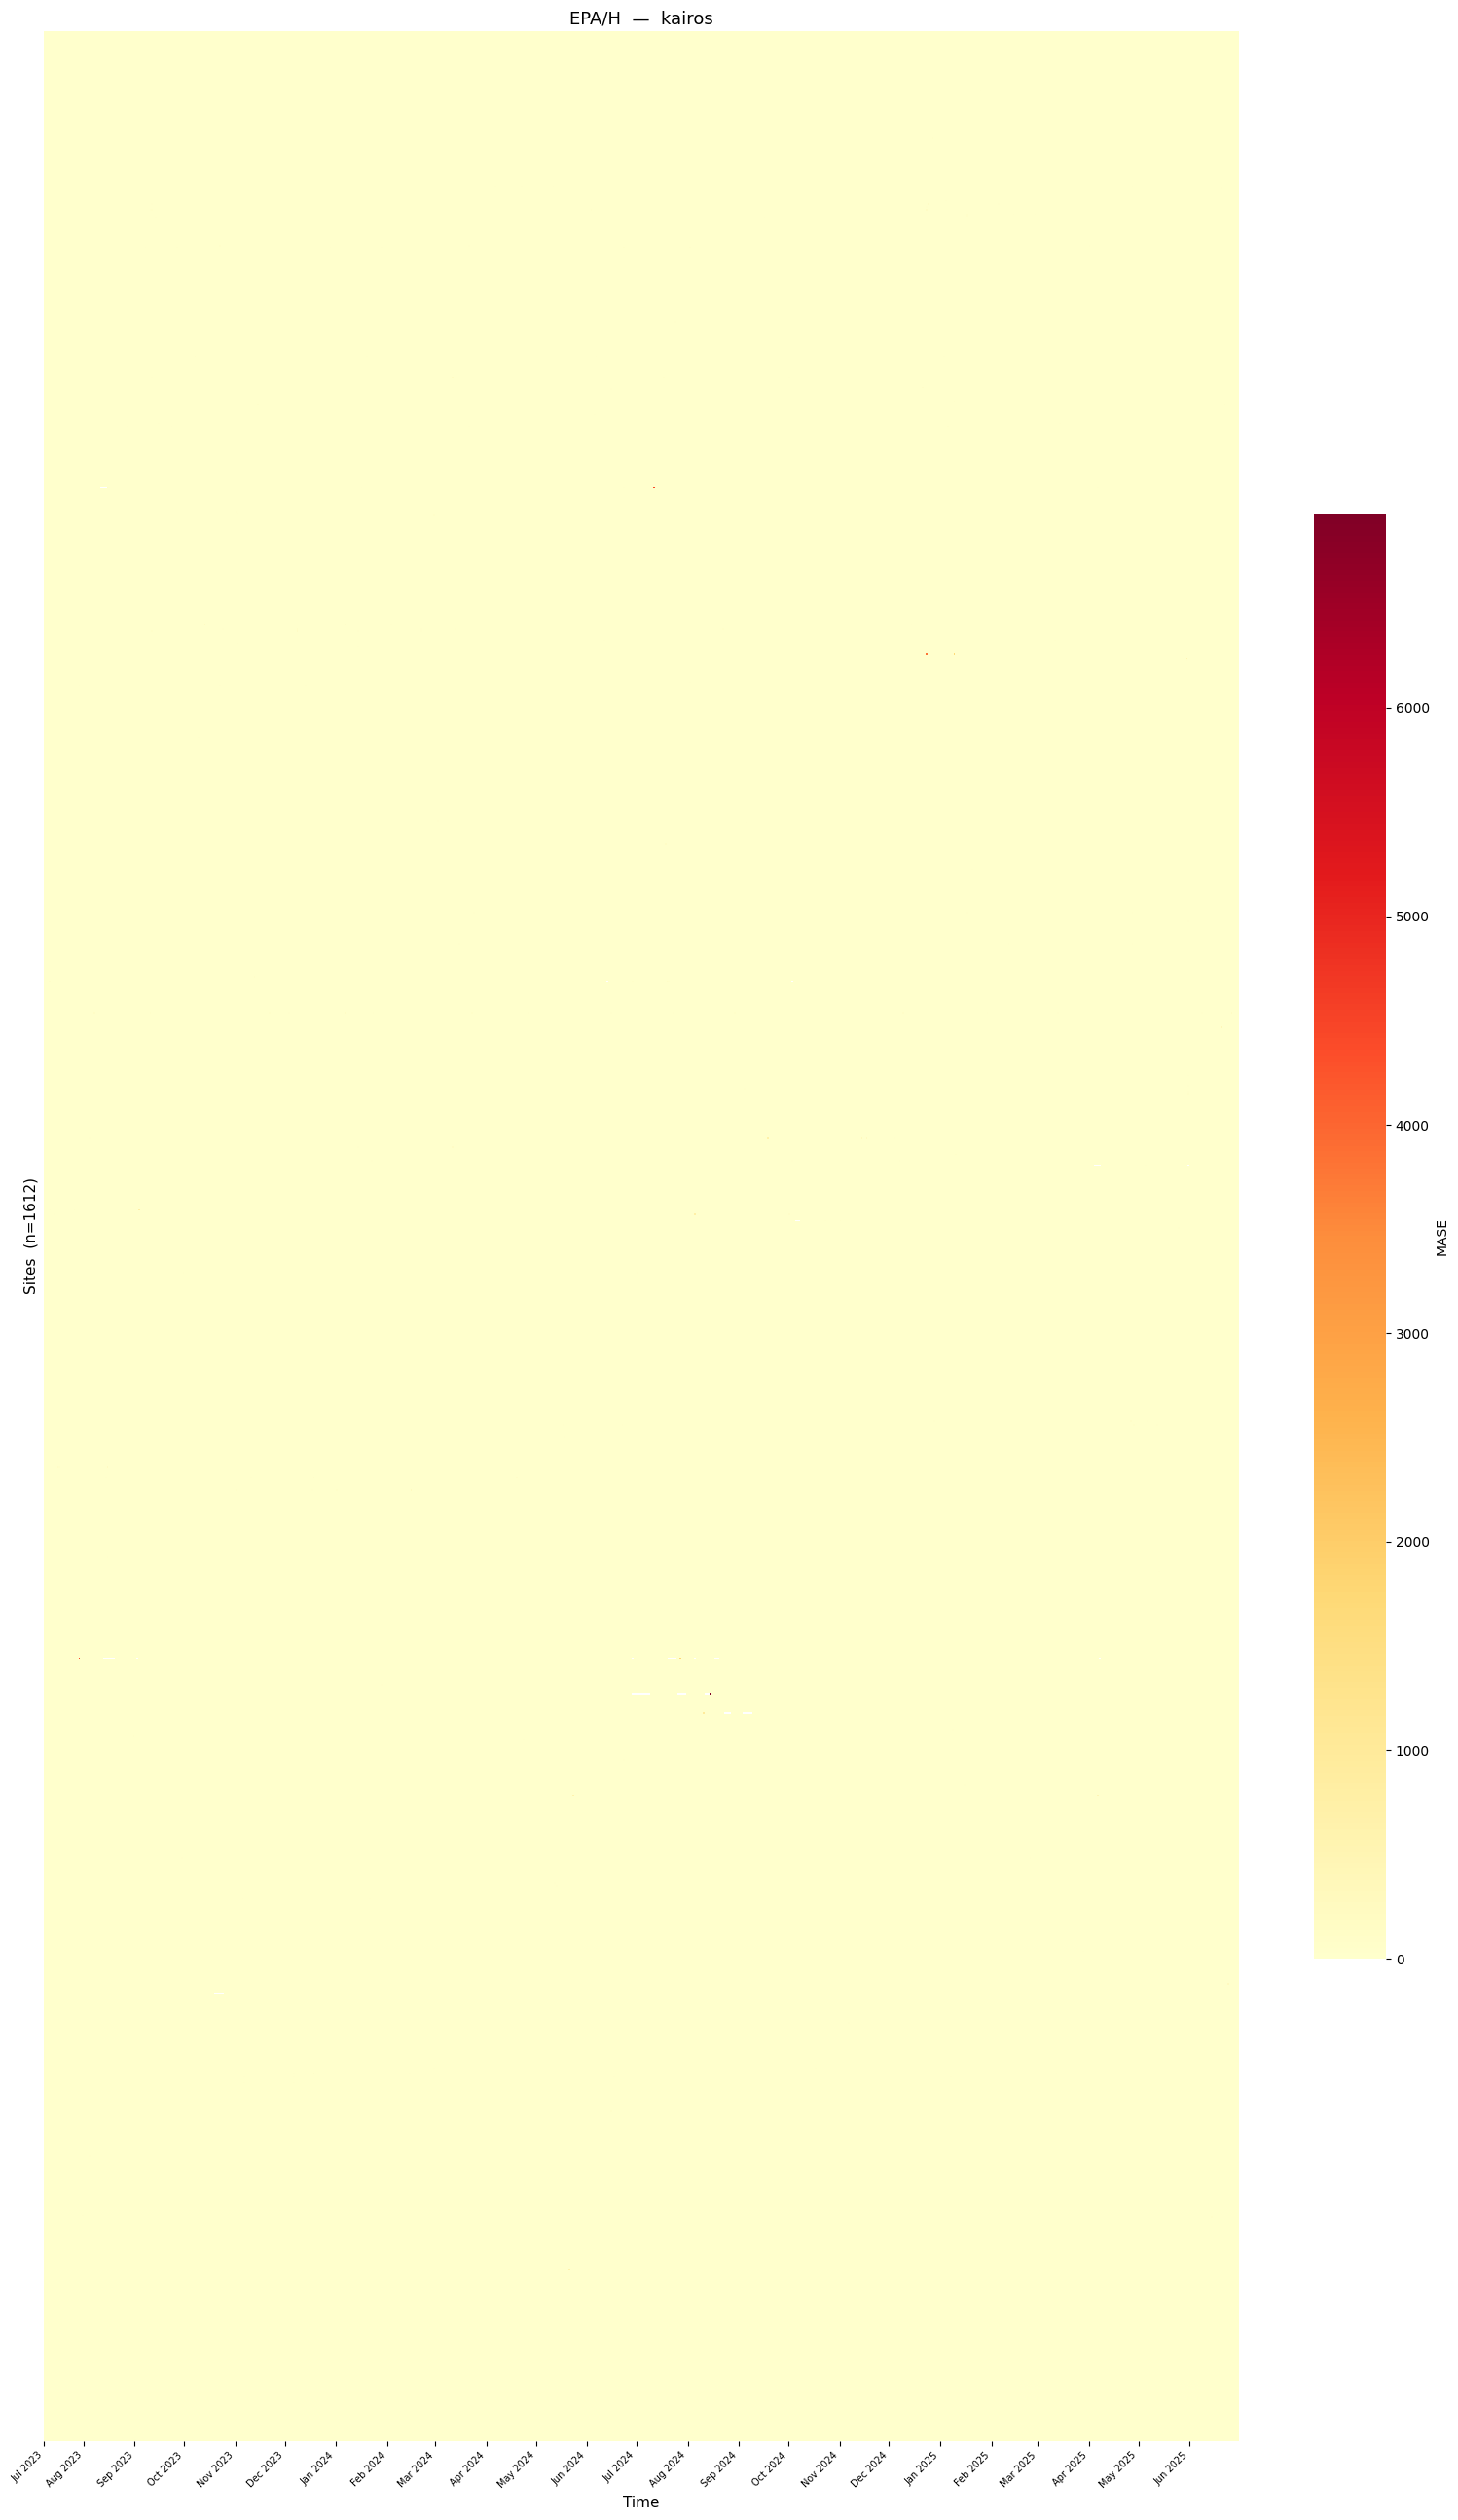

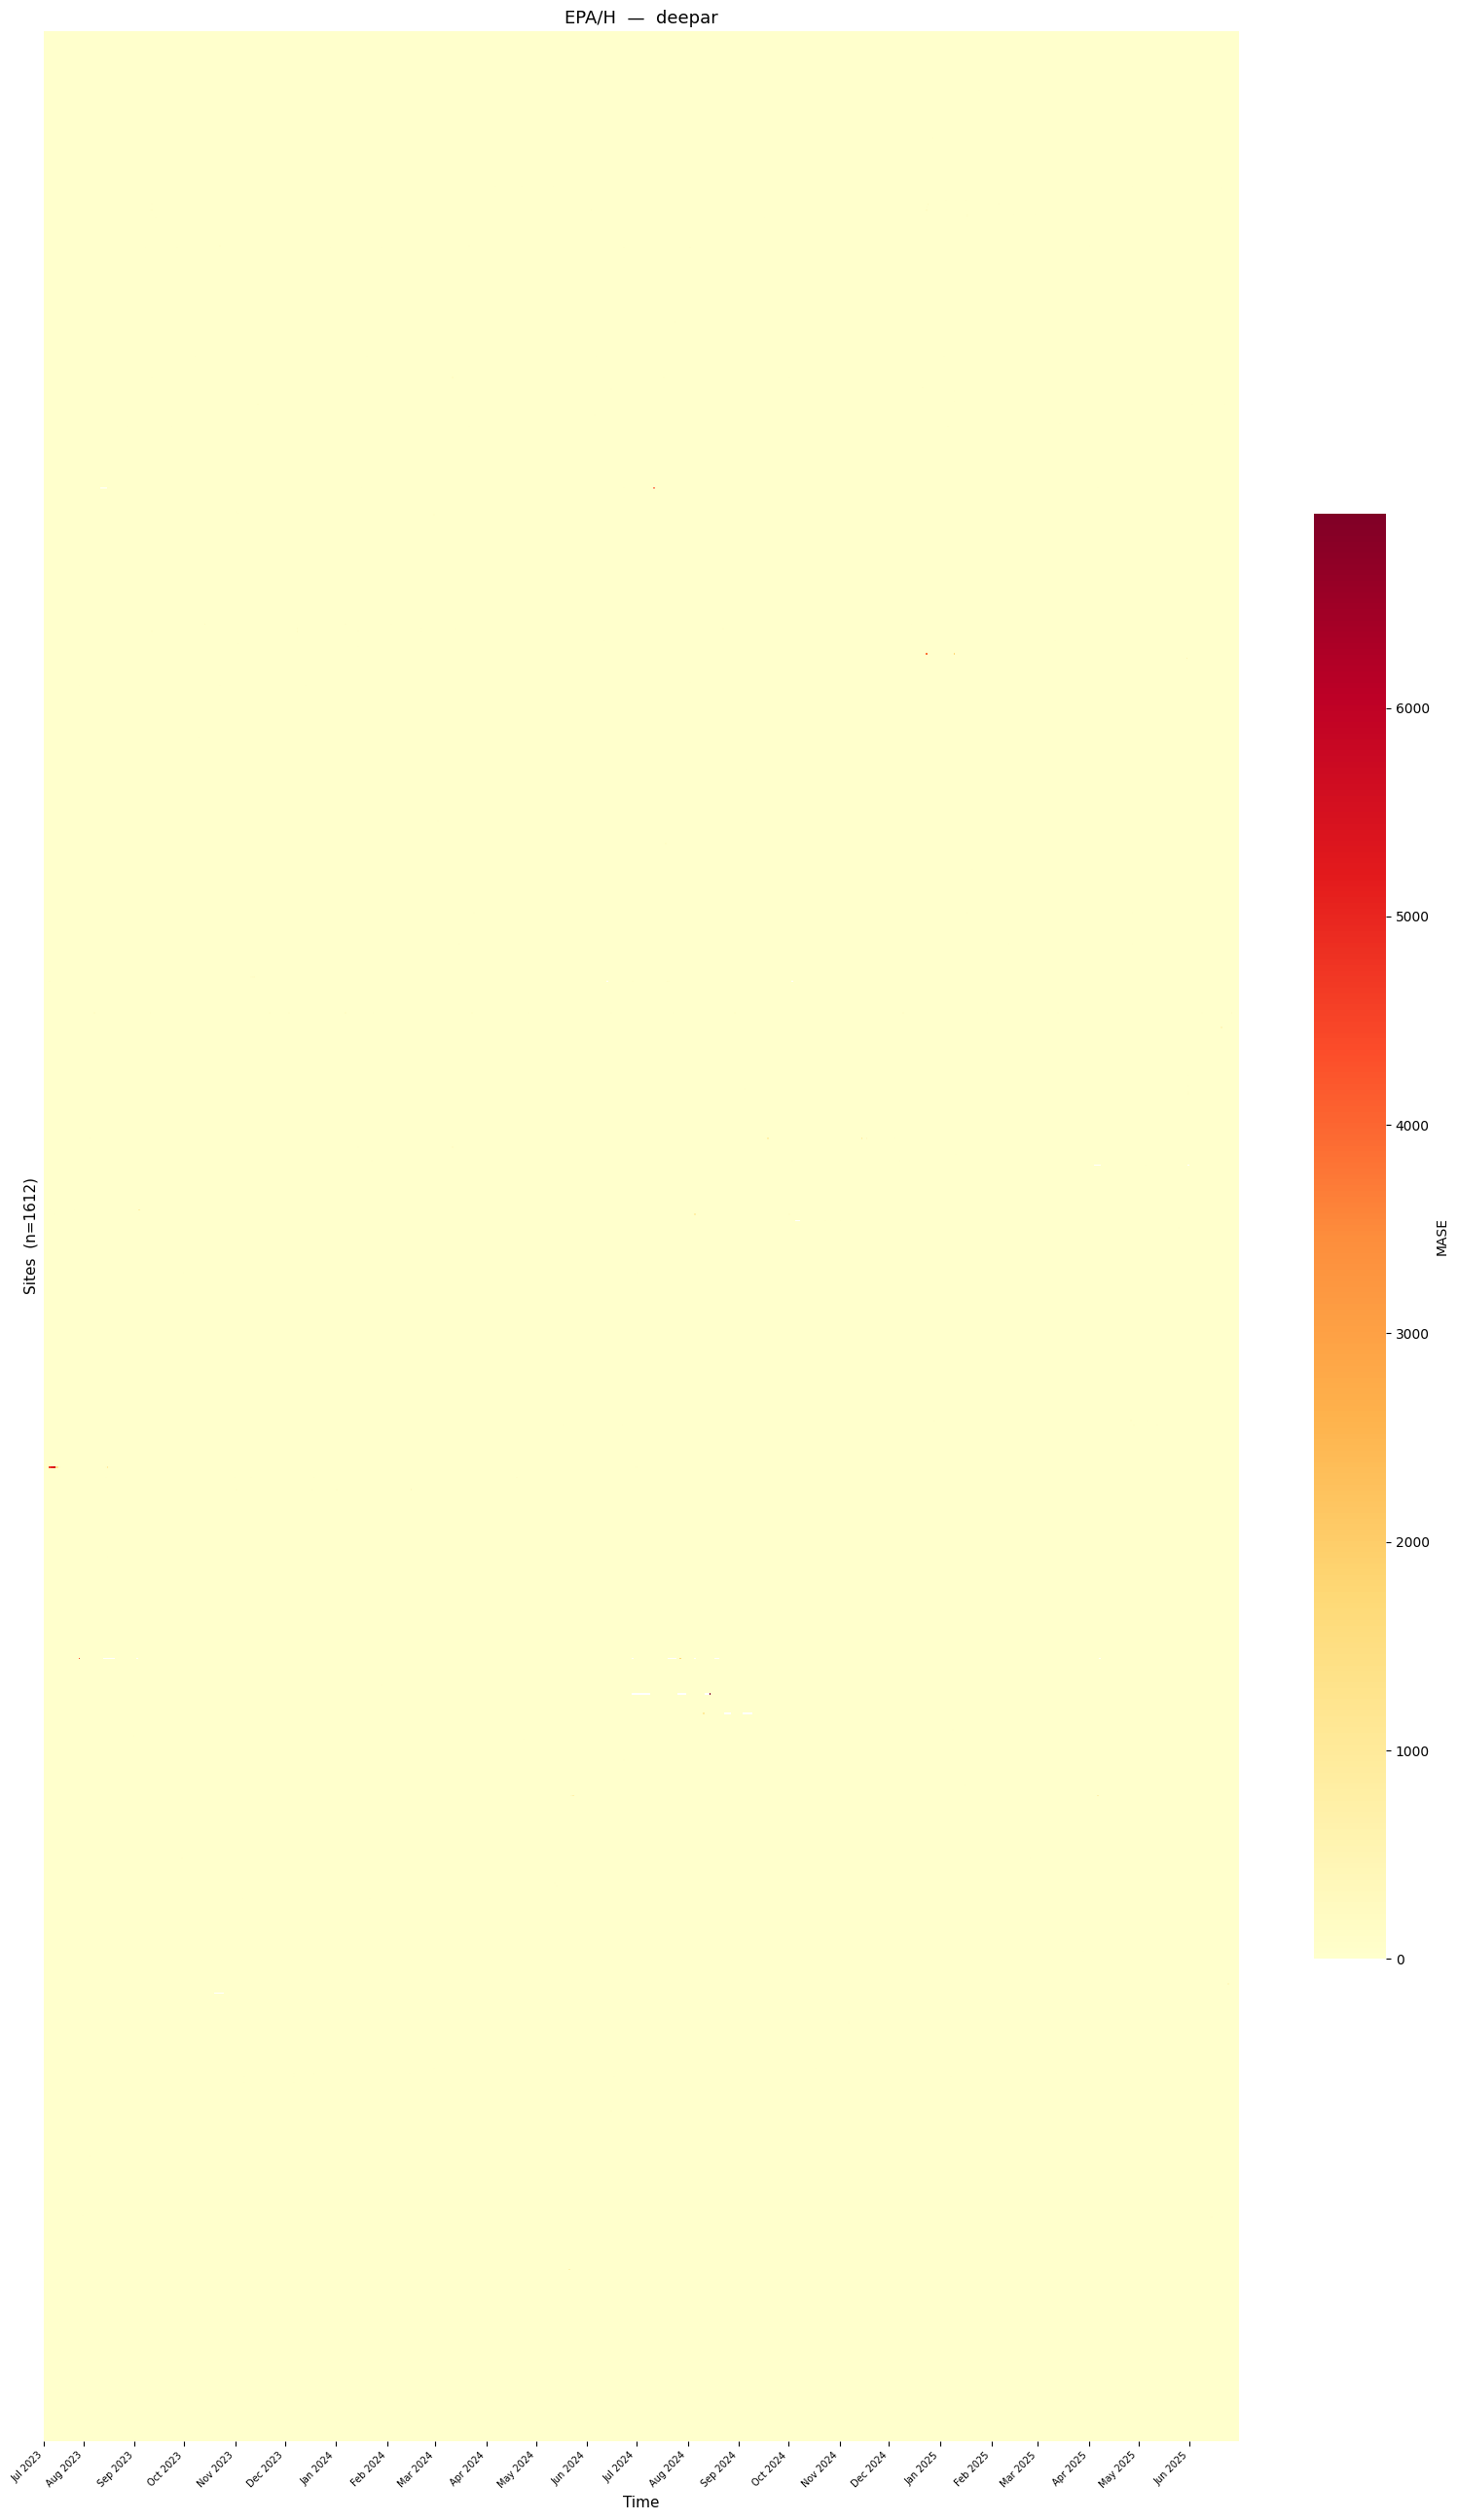

In [19]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

RESULTS_ROOT = Path("output/results")
THRESHOLD    = 50

DATASETS = ["CPCB/H", "CNEMC_SMALL/H", "EPA/H"]
MODELS   = ["TiRex", "visiontspp_base", "kairos", "deepar"]


def _excluded_sites(dataset_id: str) -> set[str]:
    """
    Mirror of the Pass-1 exclusion logic in get_per_pollutant_results:
    collect per-site mean MASE and CRPS across ALL models, exclude any site
    where either mean > THRESHOLD (50).
    """
    site_vals: dict[str, dict[str, list[float]]] = {"MASE": {}, "CRPS": {}}

    for model_dir in RESULTS_ROOT.iterdir():
        if not model_dir.is_dir():
            continue
        base = model_dir / dataset_id / "short"
        cfg_path     = base / "config.json"
        metrics_path = base / "metrics.npz"
        if not cfg_path.exists() or not metrics_path.exists():
            continue

        with open(cfg_path) as f:
            item_ids = json.load(f).get("item_ids", [])
        npz = np.load(metrics_path)

        for metric in ("MASE", "CRPS"):
            arr = npz.get(metric)
            if arr is None or arr.shape[0] != len(item_ids):
                continue
            reduce_axes = tuple(range(1, arr.ndim))
            per_series = np.nanmean(arr, axis=reduce_axes) if reduce_axes else arr
            for iid, val in zip(item_ids, per_series):
                if not np.isnan(val):
                    site_vals[metric].setdefault(iid, []).append(float(val))

    all_iids = set(site_vals["MASE"]) | set(site_vals["CRPS"])
    excluded = set()
    for iid in all_iids:
        mase_mean = np.mean(site_vals["MASE"][iid]) if site_vals["MASE"].get(iid) else 0
        crps_mean = np.mean(site_vals["CRPS"][iid]) if site_vals["CRPS"].get(iid) else 0
        if mase_mean > THRESHOLD or crps_mean > THRESHOLD:
            excluded.add(iid)
    return excluded


def _load_heatmap_data(dataset_id: str, model: str, excluded: set[str]):
    """
    Returns (site_ids, window_dates, mase_matrix) with excluded sites removed.
    MASE taken directly from metrics.npz.
    """
    base = RESULTS_ROOT / model / dataset_id / "short"
    if not (base / "metrics.npz").exists() or not (base / "predictions.npz").exists():
        return None, None, None

    with open(base / "config.json") as f:
        item_ids = json.load(f)["item_ids"]

    mase_arr = np.load(base / "metrics.npz")["MASE"]           # (n_series, n_windows, 1)
    ts_arr   = np.load(base / "predictions.npz")["timestamps"]  # (n_series, n_windows, H)

    keep_mask    = np.array([iid not in excluded for iid in item_ids])
    site_ids     = [iid for iid, k in zip(item_ids, keep_mask) if k]
    window_dates = pd.to_datetime(ts_arr[0, :, 0], unit="s")
    mase_matrix  = mase_arr[keep_mask, :, 0]                    # (n_kept, n_windows)

    return site_ids, window_dates, mase_matrix


# ── Pre-compute excluded sites once per dataset ───────────────────────────────
excluded_by_dataset = {ds: _excluded_sites(ds) for ds in DATASETS}
for ds, excl in excluded_by_dataset.items():
    print(f"{ds}: {len(excl)} site(s) excluded (mean MASE or CRPS > {THRESHOLD})")

# ── One heatmap per (dataset × model) ────────────────────────────────────────
for dataset_id in DATASETS:
    excluded = excluded_by_dataset[dataset_id]
    for model in MODELS:
        site_ids, window_dates, mase_matrix = _load_heatmap_data(dataset_id, model, excluded)
        if mase_matrix is None:
            print(f"  {dataset_id} / {model}: no data, skipping")
            continue

        # Build sparse x-tick labels: first window of each month
        month_starts = {}
        for i, dt in enumerate(window_dates):
            key = (dt.year, dt.month)
            if key not in month_starts:
                month_starts[key] = i
        xtick_pos    = list(month_starts.values())
        xtick_labels = [window_dates[i].strftime("%b %Y") for i in xtick_pos]

        fig, ax = plt.subplots(figsize=(16, max(4, len(site_ids) // 60)))
        sns.heatmap(
            mase_matrix,
            ax=ax,
            cmap="YlOrRd",
            vmin=0,
            xticklabels=False,
            yticklabels=False,
            cbar_kws={"label": "MASE", "shrink": 0.6},
        )
        ax.set_xticks(xtick_pos)
        ax.set_xticklabels(xtick_labels, rotation=45, ha="right", fontsize=7)
        ax.set_xlabel("Time", fontsize=11)
        ax.set_ylabel(f"Sites  (n={len(site_ids)})", fontsize=11)
        ax.set_title(f"{dataset_id}  —  {model}", fontsize=13)

        plt.tight_layout()
        plt.show()
